# Tacombi Project

In [63]:
import pandas as pd 
import matplotlib.pyplot as plt
import math  
import seaborn as sns 
import requests, re
from bs4 import BeautifulSoup
from random import randint
import time
import random
import numpy as np
import matplotlib as mpl
import statsmodels.api as sm
import python_weather
import asyncio
import os
import json
import datetime

mpl.style.use('fivethirtyeight')

In [97]:
#Read in file
sales_data = pd.read_csv("Tacombi Raw Data.csv")
promos2025 = pd.read_csv("2025 Campaigns.csv")
promos2024 = pd.read_csv("2024 Campaigns.csv")

sales_data.columns

C:\Users\willi\AppData\Local\Temp\ipykernel_44492\1179467107.py:2: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_data = pd.read_csv("Tacombi Raw Data.csv")


Index(['Store Name', 'Store ID', 'Order ID', 'Workflow ID', 'Dining Mode',
       'Payment Mode', 'Order Channel', 'Order Status', 'Order Date',
       'Order Day', 'Order Accept Time', 'Customer Uber-Membership Status',
       'Sales (excl. tax)', 'Tax on Sales', 'Sales (incl. tax)',
       'Order Error Adjustments', 'Tax on Order Error Adjustments',
       'Order Error Adjustments (incl. tax)', 'Price adjustments (excl. tax)',
       'Tax on Price Adjustments', 'Offers on items (incl. tax)',
       'Tax On Offers on items', 'Delivery Offer Redemptions (incl. tax)',
       'Tax On Delivery Offer Redemptions', 'Offer Redemption Fee', 'Bag Fee',
       'Marketing Adjustment', 'Total Sales after Adjustments (incl tax)',
       'Marketplace Fee', 'Marketplace fee %', 'Tax on Marketplace Fee',
       'Delivery Network Fee', 'Tax on Delivery Network Fee',
       'Order Processing Fee', 'Delivery Fee', 'Tax On Delivery Fee', 'Tips',
       'Capital payments', 'Other payments description', 'O

## Section 1: Cleaning

In [98]:
sales_data.columns

Index(['Store Name', 'Store ID', 'Order ID', 'Workflow ID', 'Dining Mode',
       'Payment Mode', 'Order Channel', 'Order Status', 'Order Date',
       'Order Day', 'Order Accept Time', 'Customer Uber-Membership Status',
       'Sales (excl. tax)', 'Tax on Sales', 'Sales (incl. tax)',
       'Order Error Adjustments', 'Tax on Order Error Adjustments',
       'Order Error Adjustments (incl. tax)', 'Price adjustments (excl. tax)',
       'Tax on Price Adjustments', 'Offers on items (incl. tax)',
       'Tax On Offers on items', 'Delivery Offer Redemptions (incl. tax)',
       'Tax On Delivery Offer Redemptions', 'Offer Redemption Fee', 'Bag Fee',
       'Marketing Adjustment', 'Total Sales after Adjustments (incl tax)',
       'Marketplace Fee', 'Marketplace fee %', 'Tax on Marketplace Fee',
       'Delivery Network Fee', 'Tax on Delivery Network Fee',
       'Order Processing Fee', 'Delivery Fee', 'Tax On Delivery Fee', 'Tips',
       'Capital payments', 'Other payments description', 'O

In [99]:
#Drop columns
sales_data = sales_data.drop(columns = ["Store ID", "Order ID", "Workflow ID", "Payment Mode", "Order Accept Time", 
                                "Tax on Sales", "Sales (incl. tax)", "Order Error Adjustments", 
                                "Tax on Order Error Adjustments", "Order Error Adjustments (incl. tax)", 
                                "Price adjustments (excl. tax)", "Tax on Price Adjustments", 
                                "Tax On Offers on items", "Tax On Delivery Offer Redemptions", "Bag Fee", 
                                "Tax on Marketplace Fee", "Delivery Network Fee", "Tax on Delivery Network Fee", 
                                "Order Processing Fee", "Tax On Delivery Fee", "Capital payments", 
                                "Other payments description", "Other payments", "Marketplace Facilitator Tax", 
                                "Backup Withholding Tax", "Payout Date", "Markup Tax", "Retailer Loyalty ID", 
                                "Payout reference ID", "Delivery Offer Redemptions (incl. tax)"])

In [100]:
sales_data.columns

Index(['Store Name', 'Dining Mode', 'Order Channel', 'Order Status',
       'Order Date', 'Order Day', 'Customer Uber-Membership Status',
       'Sales (excl. tax)', 'Offers on items (incl. tax)',
       'Offer Redemption Fee', 'Marketing Adjustment',
       'Total Sales after Adjustments (incl tax)', 'Marketplace Fee',
       'Marketplace fee %', 'Delivery Fee', 'Tips', 'Total payout ',
       'Markup Amount', 'OrderID', 'Rating', 'Rating Comment', 'Promo Net',
       'Promo %', 'Is Promo', 'is 30%', 'Hour', 'Day Part', 'Fiscal Week',
       'Fee', 'Promo', 'No Promo'],
      dtype='object')

In [101]:
#Convert date columns
sales_data["Order Date"] = pd.to_datetime(sales_data["Order Date"], origin = "1899-12-30", unit = "D")

month_map = {
    "ene": "jan", "feb": "feb", "mar": "mar", "abr": "apr", "may": "may",
    "jun": "jun", "jul": "jul", "ago": "aug", "sep": "sep", "oct": "oct",
    "nov": "nov", "dic": "dec"
}

## 2025
promos2025["Start date"] = promos2025["Start date"].astype(str).replace(month_map, regex = True)
promos2025["End date"] = promos2025["End date"].astype(str).replace(month_map, regex = True)

promos2025["Start date"] = (pd.to_datetime(promos2025["Start date"], errors = "coerce", dayfirst = True).
                                 fillna(pd.to_datetime(pd.to_numeric(promos2025["Start date"], errors = "coerce"), origin = "1899-12-30", unit = "D")))

promos2025["End date"] = (pd.to_datetime(promos2025["End date"], errors = "coerce", dayfirst = True).
                               fillna(pd.to_datetime(pd.to_numeric(promos2025["End date"], errors = "coerce"), origin = "1899-12-30", unit = "D")))

## 2024
promos2024["Start date"] = promos2024["Start date"].astype(str).replace(month_map, regex = True)
promos2024["End date"] = promos2024["End date"].astype(str).replace(month_map, regex = True)

promos2024["Start date"] = (pd.to_datetime(promos2024["Start date"], errors = "coerce", dayfirst = True).
                                 fillna(pd.to_datetime(pd.to_numeric(promos2024["Start date"], errors = "coerce"), origin = "1899-12-30", unit = "D")))

promos2024["End date"] = (pd.to_datetime(promos2024["End date"], errors = "coerce", dayfirst = True).
                               fillna(pd.to_datetime(pd.to_numeric(promos2024["End date"], errors = "coerce"), origin = "1899-12-30", unit = "D")))

In [102]:
sales_data.columns

Index(['Store Name', 'Dining Mode', 'Order Channel', 'Order Status',
       'Order Date', 'Order Day', 'Customer Uber-Membership Status',
       'Sales (excl. tax)', 'Offers on items (incl. tax)',
       'Offer Redemption Fee', 'Marketing Adjustment',
       'Total Sales after Adjustments (incl tax)', 'Marketplace Fee',
       'Marketplace fee %', 'Delivery Fee', 'Tips', 'Total payout ',
       'Markup Amount', 'OrderID', 'Rating', 'Rating Comment', 'Promo Net',
       'Promo %', 'Is Promo', 'is 30%', 'Hour', 'Day Part', 'Fiscal Week',
       'Fee', 'Promo', 'No Promo'],
      dtype='object')

In [103]:
##2025
# Get list of unique campaign offer types
offer_types = promos2025['Offer type'].dropna().unique()

# Initialize binary columns to 0
for offer in offer_types:
    sales_data[offer] = 0

# Assign campaign windows
for offer in offer_types:

    # Pull all date windows for this campaign type
    windows = promos2025.loc[promos2025['Offer type'] == offer,
                                  ['Start date', 'End date']]

    # For each window, mark the rows in sales_data
    for _, w in windows.iterrows():
        start = w['Start date']
        end = w['End date']

        mask = (sales_data['Order Date'] >= start) & (sales_data['Order Date'] <= end)

        sales_data.loc[mask, offer] = 1

In [ ]:
sales_data[sales_data["Promo"] == 1 ].sum()

In [68]:
##2024
# Get list of unique campaign offer types
offer_types = promos2024['Offer type'].dropna().unique()

# Initialize binary columns to 0
for offer in offer_types:
    sales_data[offer] = 0

# Assign campaign windows
for offer in offer_types:

    # Pull all date windows for this campaign type
    windows = promos2024.loc[promos2024['Offer type'] == offer,
                                  ['Start date', 'End date']]

    # For each window, mark the rows in sales_data
    for _, w in windows.iterrows():
        start = w['Start date']
        end = w['End date']

        mask = (sales_data['Order Date'] >= start) & (sales_data['Order Date'] <= end)

        sales_data.loc[mask, offer] = 1

In [69]:
# --- Define campaign groups ---
restrictive_campaigns = [
    "Buy 1, Get 1 Free",
    "Buy 1, get a free item",
    "Save on Menu Items"
]

non_restrictive_campaigns = [
    "25% off",
    "25% off, up to $35 ",
    "30% off",
    "30% off, up to $35 ",
    "40% off, up to $30 ",
    "Spend 30, Save 12",
    "Spend 30, Save 8",
    "Spend 35, Save 7",
    "Spend 35, Save 10",
    "Spend 35, Save 8",
    "Spend 40, Save 10",
    "Spend 40, Save 11",
    "Spend 45, Save 12"
]

# --- Ensure missing columns are treated as zero ---
for col in restrictive_campaigns + non_restrictive_campaigns:
    if col not in sales_data.columns:
        sales_data[col] = 0

# --- Create Restrictive flag ---
sales_data["Restrictive"] = (
    sales_data[restrictive_campaigns].sum(axis=1) > 0
).astype(int)

# --- Create Non-Restrictive flag ---
sales_data["Non-Restrictive"] = (
    sales_data[non_restrictive_campaigns].sum(axis=1) > 0
).astype(int)

In [70]:
# ---- Classification Column ----
# Assumes you already created the Restrictive and Non-Restrictive binary columns
sales_data['Both'] = ((sales_data['Restrictive'] == 1) & 
                      (sales_data['Non-Restrictive'] == 1)).astype(int)

# Priority for group classification:
# 1. Both
# 2. Restrictive
# 3. Non-Restrictive
def classify_campaign(row):
    if row['Both'] == 1:
        return "Both"
    elif row['Restrictive'] == 1:
        return "Restrictive"
    elif row['Non-Restrictive'] == 1:
        return "Non-Restrictive"
    else:
        return "None"

sales_data["Campaign Type"] = sales_data.apply(classify_campaign, axis=1)

## Section 2: KPI Tables

In [71]:
##2025
# --- 1. Ensure date columns are datetime ---
promos2025['Start date'] = pd.to_datetime(promos2025['Start date'])
promos2025['End date'] = pd.to_datetime(promos2025['End date'])

# --- 2. Clean numeric columns ---
promos2025['Sales (USD)'] = (
    promos2025['Sales (USD)']
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
promos2025['New customers'] = pd.to_numeric(promos2025['New customers'], errors='coerce')
promos2025['Orders'] = pd.to_numeric(promos2025['Orders'], errors='coerce')

# --- 3. Compute duration in days (inclusive) ---
promos2025['duration_days'] = (promos2025['End date'] - promos2025['Start date']).dt.days + 1

# --- 4. Group by Offer Type and compute aggregated metrics ---
kpi_table_2025 = (
    promos2025.groupby('Offer type')
    .agg(
        Total_Sales=('Sales (USD)', 'sum'),
        Total_New_Customers=('New customers', 'sum'),
        Total_Orders=('Orders', 'sum'),
        Total_Active_Days=('duration_days', 'sum')
    )
    .reset_index()
)

# --- 5. Compute KPIs ---
kpi_table_2025['Sales Per Day'] = kpi_table_2025['Total_Sales'] / kpi_table_2025['Total_Active_Days']
kpi_table_2025['New Customers Per Day'] = kpi_table_2025['Total_New_Customers'] / kpi_table_2025['Total_Active_Days']
kpi_table_2025['AOV'] = kpi_table_2025['Total_Sales'] / kpi_table_2025['Total_Orders']

# --- 6. Format numbers ---
kpi_table_2025['Sales Per Day'] = kpi_table_2025['Sales Per Day'].round(2)
kpi_table_2025['New Customers Per Day'] = kpi_table_2025['New Customers Per Day'].round(2)
kpi_table_2025['AOV'] = kpi_table_2025['AOV'].round(2)
kpi_table_2025['Total_Sales'] = kpi_table_2025['Total_Sales'].round(0).astype(int)
kpi_table_2025['Total_New_Customers'] = kpi_table_2025['Total_New_Customers'].astype(int)
kpi_table_2025['Total_Orders'] = kpi_table_2025['Total_Orders'].astype(int)
kpi_table_2025['Total_Active_Days'] = kpi_table_2025['Total_Active_Days'].astype(int)

# --- 7. Rank by increasing Sales Per Day ---
kpi_table_2025 = kpi_table_2025.sort_values('Sales Per Day', ascending=True).reset_index(drop=True)

kpi_table_2025

,Offer type,Total_Sales,Total_New_Customers,Total_Orders,Total_Active_Days,Sales Per Day,New Customers Per Day,AOV
0,"Buy 1, get a free item",18625,177,391,2202,8.46,0.08,47.63
1,"Spend 45, Save 15",19467,98,281,232,83.91,0.42,69.28
2,"Spend 35, Save 7",231191,3889,3895,1456,158.79,2.67,59.36
3,"Spend 35, Save 10",42602,739,739,208,204.82,3.55,57.65
4,"Spend 35, Save 8",502023,1572,9092,2124,236.36,0.74,55.22
5,Save on Menu Items,480971,7802,10593,1885,255.16,4.14,45.40
6,"40% off, up to $30",7607,67,167,28,271.68,2.39,45.55
7,25% off,106680,825,2412,367,290.68,2.25,44.23
8,30% off,12665,268,270,41,308.90,6.54,46.91
9,"Spend 30, Save 8",1055666,12622,21171,3065,344.43,4.12,49.86


In [72]:
##2024
# --- 1. Ensure date columns are datetime ---
promos2024['Start date'] = pd.to_datetime(promos2024['Start date'])
promos2024['End date'] = pd.to_datetime(promos2024['End date'])

# --- 2. Clean numeric columns ---
promos2024['Sales (USD)'] = (
    promos2024['Sales (USD)']
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
promos2024['New customers'] = pd.to_numeric(promos2024['New customers'], errors='coerce')
promos2024['Orders'] = pd.to_numeric(promos2024['Orders'], errors='coerce')

# --- 3. Compute duration in days (inclusive) ---
promos2024['duration_days'] = (promos2024['End date'] - promos2024['Start date']).dt.days + 1

# --- 4. Group by Offer Type and compute aggregated metrics ---
kpi_table_2024 = (
    promos2024.groupby('Offer type')
    .agg(
        Total_Sales=('Sales (USD)', 'sum'),
        Total_New_Customers=('New customers', 'sum'),
        Total_Orders=('Orders', 'sum'),
        Total_Active_Days=('duration_days', 'sum')
    )
    .reset_index()
)

# --- 5. Compute KPIs ---
kpi_table_2024['Sales Per Day'] = kpi_table_2024['Total_Sales'] / kpi_table_2024['Total_Active_Days']
kpi_table_2024['New Customers Per Day'] = kpi_table_2024['Total_New_Customers'] / kpi_table_2024['Total_Active_Days']
kpi_table_2024['AOV'] = kpi_table_2024['Total_Sales'] / kpi_table_2024['Total_Orders']

# --- 6. Format numbers ---
kpi_table_2024['Sales Per Day'] = kpi_table_2024['Sales Per Day'].round(2)
kpi_table_2024['New Customers Per Day'] = kpi_table_2024['New Customers Per Day'].round(2)
kpi_table_2024['AOV'] = kpi_table_2024['AOV'].round(2)
kpi_table_2024['Total_Sales'] = kpi_table_2024['Total_Sales'].round(0).astype(int)
kpi_table_2024['Total_New_Customers'] = kpi_table_2024['Total_New_Customers'].astype(int)
kpi_table_2024['Total_Orders'] = kpi_table_2024['Total_Orders'].astype(int)
kpi_table_2024['Total_Active_Days'] = kpi_table_2024['Total_Active_Days'].astype(int)

# --- 7. Rank by increasing Sales Per Day ---
kpi_table_2024 = kpi_table_2024.sort_values('Sales Per Day', ascending=True).reset_index(drop=True)

kpi_table_2024

,Offer type,Total_Sales,Total_New_Customers,Total_Orders,Total_Active_Days,Sales Per Day,New Customers Per Day,AOV
0,"Spend 40, Save 10",4489,70,70,44,102.02,1.59,64.13
1,"Spend 45, Save 12",8557,123,123,44,194.48,2.80,69.57
2,"Buy 1, Get 1 Free",549534,6959,13625,1464,375.36,4.75,40.33
3,"30% off, up to $35",137881,1197,2562,348,396.21,3.44,53.82
4,"25% off, up to $35",483495,3603,9289,550,879.08,6.55,52.05


In [73]:
##2025
# Copy KPI table
score_df_2025 = kpi_table_2025.copy()

# Ensure we have correct column names
# If your KPI table has different names, adjust here
score_df_2025 = score_df_2025.rename(columns={
    'Total_Sales': 'Total Sales (USD)',
    'Total_New_Customers': 'Total New Customers',
    'Total_Orders': 'Total Orders',
    'Total_Active_Days': 'Total Active Days'
})

# --- Min-max normalize the KPI columns ---
for col in ["Sales Per Day", "New Customers Per Day", "AOV"]:
    min_val = score_df_2025[col].min()
    max_val = score_df_2025[col].max()
    score_df_2025[col + "_norm"] = (score_df_2025[col] - min_val) / (max_val - min_val) if max_val != min_val else 1

# --- Apply weights ---
w_sales = 0.40
w_newcust = 0.40
w_aov = 0.20

score_df_2025["Performance_Score"] = (
      w_sales * score_df_2025["Sales Per Day_norm"]
    + w_newcust * score_df_2025["New Customers Per Day_norm"]
    + w_aov * score_df_2025["AOV_norm"]
)

# Scale to 0-100
score_df_2025["Performance_Score"] = (score_df_2025["Performance_Score"] * 100).round(1)

# Sort descending
score_df_2025 = score_df_2025.sort_values("Performance_Score", ascending=False).reset_index(drop=True)

# Keep only relevant columns
cols_to_keep = [
    "Offer type",
    "Performance_Score",
    "Sales Per Day",
    "New Customers Per Day",
    "AOV",
    "Total Sales (USD)",
    "Total Orders",
    "Total New Customers",
    "Total Active Days"
]

score_df_2025 = score_df_2025[cols_to_keep]

score_df_2025

,Offer type,Performance_Score,Sales Per Day,New Customers Per Day,AOV,Total Sales (USD),Total Orders,Total New Customers,Total Active Days
0,"Buy 1, Get 1 Free",80.0,943.23,11.69,44.24,3192834,72177,39585,3385
1,"Spend 40, Save 11",79.6,708.58,9.28,66.73,527892,7911,6911,745
2,30% off,37.3,308.90,6.54,46.91,12665,270,268,41
3,"Spend 30, Save 8",32.8,344.43,4.12,49.86,1055666,21171,12622,3065
4,"Spend 35, Save 10",31.1,204.82,3.55,57.65,42602,739,739,208
5,"Spend 30, Save 12",30.4,393.28,3.35,47.58,63712,1339,543,162
6,"Spend 35, Save 7",27.4,158.79,2.67,59.36,231191,3895,3889,1456
7,Save on Menu Items,25.5,255.16,4.14,45.40,480971,10593,7802,1885
8,"Spend 45, Save 15",24.4,83.91,0.42,69.28,19467,281,98,232
9,"Spend 35, Save 8",20.8,236.36,0.74,55.22,502023,9092,1572,2124


In [74]:
##2024
# Copy KPI table
score_df_2024 = kpi_table_2024.copy()

# Ensure we have correct column names
# If your KPI table has different names, adjust here
score_df_2024 = score_df_2024.rename(columns={
    'Total_Sales': 'Total Sales (USD)',
    'Total_New_Customers': 'Total New Customers',
    'Total_Orders': 'Total Orders',
    'Total_Active_Days': 'Total Active Days'
})

# --- Min-max normalize the KPI columns ---
for col in ["Sales Per Day", "New Customers Per Day", "AOV"]:
    min_val = score_df_2024[col].min()
    max_val = score_df_2024[col].max()
    score_df_2024[col + "_norm"] = (score_df_2024[col] - min_val) / (max_val - min_val) if max_val != min_val else 1

# --- Apply weights ---
w_sales = 0.40
w_newcust = 0.40
w_aov = 0.20

score_df_2024["Performance_Score"] = (
      w_sales * score_df_2024["Sales Per Day_norm"]
    + w_newcust * score_df_2024["New Customers Per Day_norm"]
    + w_aov * score_df_2024["AOV_norm"]
)

# Scale to 0-100
score_df_2024["Performance_Score"] = (score_df_2024["Performance_Score"] * 100).round(1)

# Sort descending
score_df_2024 = score_df_2024.sort_values("Performance_Score", ascending=False).reset_index(drop=True)

# Keep only relevant columns
cols_to_keep = [
    "Offer type",
    "Performance_Score",
    "Sales Per Day",
    "New Customers Per Day",
    "AOV",
    "Total Sales (USD)",
    "Total Orders",
    "Total New Customers",
    "Total Active Days"
]

score_df_2024 = score_df_2024[cols_to_keep]

score_df_2024

,Offer type,Performance_Score,Sales Per Day,New Customers Per Day,AOV,Total Sales (USD),Total Orders,Total New Customers,Total Active Days
0,"25% off, up to $35",88.0,879.08,6.55,52.05,483495,9289,3603,550
1,"Buy 1, Get 1 Free",39.6,375.36,4.75,40.33,549534,13625,6959,1464
2,"30% off, up to $35",39.3,396.21,3.44,53.82,137881,2562,1197,348
3,"Spend 45, Save 12",34.5,194.48,2.80,69.57,8557,123,123,44
4,"Spend 40, Save 10",16.3,102.02,1.59,64.13,4489,70,70,44


In [75]:
#TESTING
# --- Copy data to avoid mutation ---
df = sales_data.copy()

# --- Exclude cancelled orders ---
df = df[df["Order Status"].str.lower() != "cancelled"].copy()

# --- Ensure numeric columns ---
numeric_cols = [
    "Sales (excl. tax)",
    "Promo Net"
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# --- Define Promo flag based on redemption ---
df["Promo_Flag"] = np.where(df["Promo Net"] != 0, 1, 0)

# --- Absolute promo dollars ---
df["Promo_Dollars"] = df["Promo Net"].abs()

In [76]:
def kpi_summary(data, segment_col, segment_values):
    rows = []

    for val in segment_values:
        subset = data[data[segment_col] == val]

        total_orders = len(subset)
        promo_orders = subset["Promo_Flag"].sum()
        total_sales = subset["Sales (excl. tax)"].sum()
        promo_sales = subset.loc[subset["Promo_Flag"] == 1, "Sales (excl. tax)"].sum()
        promo_dollars = subset["Promo_Dollars"].sum()

        rows.append({
            segment_col: val,
            "Orders": int(total_orders),
            "AOV ($)": round(total_sales / total_orders, 2) if total_orders > 0 else 0,
            "% Promo Orders": round(promo_orders / total_orders * 100, 1) if total_orders > 0 else 0,
            "Promo $ as % of Sales": round(promo_dollars / total_sales * 100, 1) if total_sales > 0 else 0,
            "Avg Promo $ / Promo Order": round(promo_dollars / promo_orders, 2) if promo_orders > 0 else 0
        })

    return pd.DataFrame(rows)

In [77]:
promo_vs_no_promo = kpi_summary(
    df,
    segment_col="Promo_Flag",
    segment_values=[1, 0]
).replace({"Promo_Flag": {1: "Promo Orders", 0: "No-Promo Orders"}})

promo_vs_no_promo

,Promo_Flag,Orders,AOV ($),% Promo Orders,Promo $ as % of Sales,Avg Promo $ / Promo Order
0,Promo Orders,117763,45.92,100.0,28.8,13.24
1,No-Promo Orders,310178,31.27,0.0,0.0,0.00


In [78]:
promo_only = df[df["Promo_Flag"] == 1].copy()

promo_only["Campaign Segment"] = np.select(
    [
        (promo_only["Restrictive"] == 1) & (promo_only["Non-Restrictive"] == 0),
        (promo_only["Non-Restrictive"] == 1) & (promo_only["Restrictive"] == 0),
        (promo_only["Both"] == 1)
    ],
    [
        "Restrictive Only",
        "Non-Restrictive Only",
        "Both"
    ],
    default="Unclassified"
)

campaign_split = kpi_summary(
    promo_only,
    segment_col="Campaign Segment",
    segment_values=["Restrictive Only", "Non-Restrictive Only", "Both"]
)

campaign_split

,Campaign Segment,Orders,AOV ($),% Promo Orders,Promo $ as % of Sales,Avg Promo $ / Promo Order
0,Restrictive Only,20504,40.37,100.0,24.9,10.06
1,Non-Restrictive Only,12978,49.46,100.0,26.8,13.24
2,Both,84280,46.72,100.0,30.0,14.02


In [79]:
df["Uber One"] = df["Customer Uber-Membership Status"].map({
    "Uber One member": "Uber One Member",
    "Non-member": "Non-Member"
})

uber_one_split = kpi_summary(
    df,
    segment_col="Uber One",
    segment_values=["Uber One Member", "Non-Member"]
)

uber_one_split

,Uber One,Orders,AOV ($),% Promo Orders,Promo $ as % of Sales,Avg Promo $ / Promo Order
0,Uber One Member,276726,36.68,30.9,11.3,13.40
1,Non-Member,137020,36.17,23.5,8.3,12.82


In [80]:
delivery_split = kpi_summary(
    df,
    segment_col="Dining Mode",
    segment_values=df["Dining Mode"].dropna().unique().tolist()
)

delivery_split

,Dining Mode,Orders,AOV ($),% Promo Orders,Promo $ as % of Sales,Avg Promo $ / Promo Order
0,Delivery - Partner Using Uber App,368884,37.03,27.3,9.6,13.06
1,Pickup,44862,32.26,37.8,16.8,14.35


In [81]:
pd.set_option("display.max_colwidth", None)


df["Combined Segment"] = (
    df["Dining Mode"].fillna("Unknown")
    + " | "
    + df["Uber One"].fillna("Unknown")
    + " | "
    + np.where(df["Promo_Flag"] == 1, "Promo", "No Promo")
)

combined_kpis = (
    df.groupby("Combined Segment")
      .apply(lambda x: pd.Series({
          "Orders": len(x),
          "AOV ($)": round(x["Sales (excl. tax)"].mean(), 2),
          "% Promo Orders": round(x["Promo_Flag"].mean() * 100, 1),
          "Promo $ as % of Sales": round(x["Promo_Dollars"].sum() / x["Sales (excl. tax)"].sum() * 100, 1)
      }))
      .reset_index()
      .sort_values("Orders", ascending=False)
)

combined_kpis

C:\Users\willi\AppData\Local\Temp\ipykernel_44492\3708976005.py:18: RuntimeWarning: invalid value encountered in scalar divide
  "Promo $ as % of Sales": round(x["Promo_Dollars"].sum() / x["Sales (excl. tax)"].sum() * 100, 1)
C:\Users\willi\AppData\Local\Temp\ipykernel_44492\3708976005.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,Combined Segment,Orders,AOV ($),% Promo Orders,Promo $ as % of Sales
2,Delivery - Partner Using Uber App | Uber One Member | No Promo,176041.0,33.06,0.0,0.0
0,Delivery - Partner Using Uber App | Non-Member | No Promo,92017.0,33.75,0.0,0.0
3,Delivery - Partner Using Uber App | Uber One Member | Promo,74922.0,46.38,100.0,28.5
1,Delivery - Partner Using Uber App | Non-Member | Promo,25904.0,48.54,100.0,25.9
6,Pickup | Uber One Member | No Promo,15138.0,27.89,0.0,0.0
8,Unknown | Unknown | No Promo,14195.0,0.00,0.0,NaN
4,Pickup | Non-Member | No Promo,12787.0,27.38,0.0,0.0
7,Pickup | Uber One Member | Promo,10625.0,40.72,100.0,36.1
5,Pickup | Non-Member | Promo,6312.0,38.41,100.0,35.8


## Section 3: Customer Ratio Analysis

In [82]:
##2025
existing_vs_new_table_2025 = kpi_table_2025.copy()

# I'm making the assumtion here that Total_Orders = Total_New_Customers	+ Total_Existing_Customers	
# By expressing it as a ratio we can see which promos are the most/least popular with new customers

existing_vs_new_table_2025["Total_Existing_Customers"] = existing_vs_new_table_2025["Total_Orders"] - existing_vs_new_table_2025["Total_New_Customers"]
existing_vs_new_table_2025["New_Customer_Ratio"] = existing_vs_new_table_2025["Total_New_Customers"] / existing_vs_new_table_2025["Total_Orders"]
existing_vs_new_table_2025["Existing_Customer_Ratio"] = existing_vs_new_table_2025["Total_Existing_Customers"] / existing_vs_new_table_2025["Total_Orders"]

# Sort descending
existing_vs_new_table_2025 = existing_vs_new_table_2025.sort_values("New_Customer_Ratio", ascending=True).reset_index(drop=True)

# Keep only relevant columns
cols_to_keep = [
    "Offer type",
    "New_Customer_Ratio",
    "Total_New_Customers",
    "Existing_Customer_Ratio",
    "Total_Existing_Customers",
    "Total_Orders"
]

existing_vs_new_table_2025 = existing_vs_new_table_2025[cols_to_keep]

existing_vs_new_table_2025

,Offer type,New_Customer_Ratio,Total_New_Customers,Existing_Customer_Ratio,Total_Existing_Customers,Total_Orders
0,"Spend 35, Save 8",0.172899,1572,0.827101,7520,9092
1,25% off,0.342040,825,0.657960,1587,2412
2,"Spend 45, Save 15",0.348754,98,0.651246,183,281
3,"40% off, up to $30",0.401198,67,0.598802,100,167
4,"Spend 30, Save 12",0.405527,543,0.594473,796,1339
5,"Buy 1, get a free item",0.452685,177,0.547315,214,391
6,"Buy 1, Get 1 Free",0.548443,39585,0.451557,32592,72177
7,"Spend 30, Save 8",0.596193,12622,0.403807,8549,21171
8,Save on Menu Items,0.736524,7802,0.263476,2791,10593
9,"Spend 40, Save 11",0.873594,6911,0.126406,1000,7911


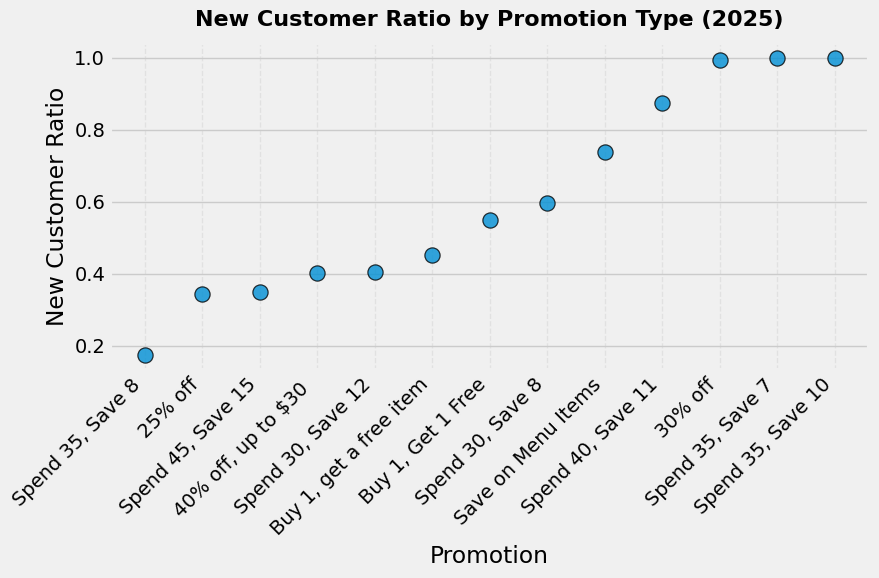

In [83]:
##2025
#Plot for new customer ratios
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=existing_vs_new_table_2025,
    y="New_Customer_Ratio",
    x="Offer type",
    s=120,                 
    alpha=0.8,             
    edgecolor="black"
)

plt.title(
    "New Customer Ratio by Promotion Type (2025)",
    fontsize=16,
    weight="bold",
    pad=12
)

plt.xlabel("Promotion")
plt.ylabel("New Customer Ratio")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [84]:
##2024
existing_vs_new_table_2024 = kpi_table_2024.copy()

# I'm making the assumtion here that Total_Orders = Total_New_Customers	+ Total_Existing_Customers	
# By expressing it as a ratio we can see which promos are the most/least popular with new customers

existing_vs_new_table_2024["Total_Existing_Customers"] = existing_vs_new_table_2024["Total_Orders"] - existing_vs_new_table_2024["Total_New_Customers"]
existing_vs_new_table_2024["New_Customer_Ratio"] = existing_vs_new_table_2024["Total_New_Customers"] / existing_vs_new_table_2024["Total_Orders"]
existing_vs_new_table_2024["Existing_Customer_Ratio"] = existing_vs_new_table_2024["Total_Existing_Customers"] / existing_vs_new_table_2024["Total_Orders"]

# Sort descending
existing_vs_new_table_2024 = existing_vs_new_table_2024.sort_values("New_Customer_Ratio", ascending=True).reset_index(drop=True)

# Keep only relevant columns
cols_to_keep = [
    "Offer type",
    "New_Customer_Ratio",
    "Total_New_Customers",
    "Existing_Customer_Ratio",
    "Total_Existing_Customers",
    "Total_Orders"
]

existing_vs_new_table_2024 = existing_vs_new_table_2024[cols_to_keep]

existing_vs_new_table_2024

,Offer type,New_Customer_Ratio,Total_New_Customers,Existing_Customer_Ratio,Total_Existing_Customers,Total_Orders
0,"25% off, up to $35",0.387878,3603,0.612122,5686,9289
1,"30% off, up to $35",0.467213,1197,0.532787,1365,2562
2,"Buy 1, Get 1 Free",0.510752,6959,0.489248,6666,13625
3,"Spend 45, Save 12",1.000000,123,0.000000,0,123
4,"Spend 40, Save 10",1.000000,70,0.000000,0,70


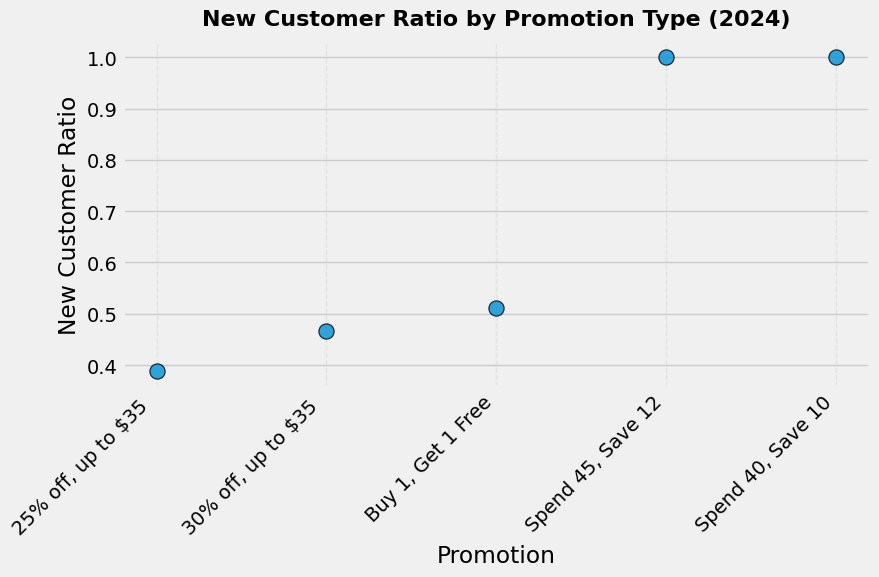

In [85]:
##2024
#Plot for new customer ratios
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=existing_vs_new_table_2024,
    y="New_Customer_Ratio",
    x="Offer type",
    s=120,                 
    alpha=0.8,             
    edgecolor="black"
)

plt.title(
    "New Customer Ratio by Promotion Type (2024)",
    fontsize=16,
    weight="bold",
    pad=12
)

plt.xlabel("Promotion")
plt.ylabel("New Customer Ratio")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Section 3.1: Audience Filtered Customer Ratio Analysis

In [86]:
##2025

#audience_filtered_table

all_customers_promos_2025 = promos2025[promos2025["Audience"] == "All customers"]

all_customers_table_2025 = (
    all_customers_promos_2025.groupby('Offer type')
    .agg(
        Total_Sales=('Sales (USD)', 'sum'),
        Total_New_Customers=('New customers', 'sum'),
        Total_Orders=('Orders', 'sum'),
        Total_Active_Days=('duration_days', 'sum')
    )
    .reset_index()
)

all_customers_table_2025["Total_Existing_Customers"] = all_customers_table_2025["Total_Orders"] - all_customers_table_2025["Total_New_Customers"]
all_customers_table_2025["New_Customer_Ratio"] = all_customers_table_2025["Total_New_Customers"] / all_customers_table_2025["Total_Orders"]
all_customers_table_2025["Existing_Customer_Ratio"] = all_customers_table_2025["Total_Existing_Customers"] / all_customers_table_2025["Total_Orders"]


all_customers_table_2025 = all_customers_table_2025.sort_values("New_Customer_Ratio", ascending=True).reset_index(drop=True)

all_customers_table_2025


,Offer type,Total_Sales,Total_New_Customers,Total_Orders,Total_Active_Days,Total_Existing_Customers,New_Customer_Ratio,Existing_Customer_Ratio
0,"Spend 40, Save 11",68053.0,222,1218,378,996,0.182266,0.817734
1,"Spend 35, Save 8",299518.0,1227,5410,1566,4183,0.226802,0.773198
2,25% off,106680.0,825,2412,367,1587,0.342040,0.657960
3,"Buy 1, Get 1 Free",2367557.0,22419,54985,3018,32566,0.407729,0.592271
4,"Spend 30, Save 8",578115.0,4954,11819,383,6865,0.419156,0.580844
5,"Buy 1, get a free item",18625.0,177,391,2202,214,0.452685,0.547315
6,Save on Menu Items,258453.0,2416,5199,687,2783,0.464705,0.535295
7,"40% off, up to $30",0.0,0,0,9,0,NaN,NaN


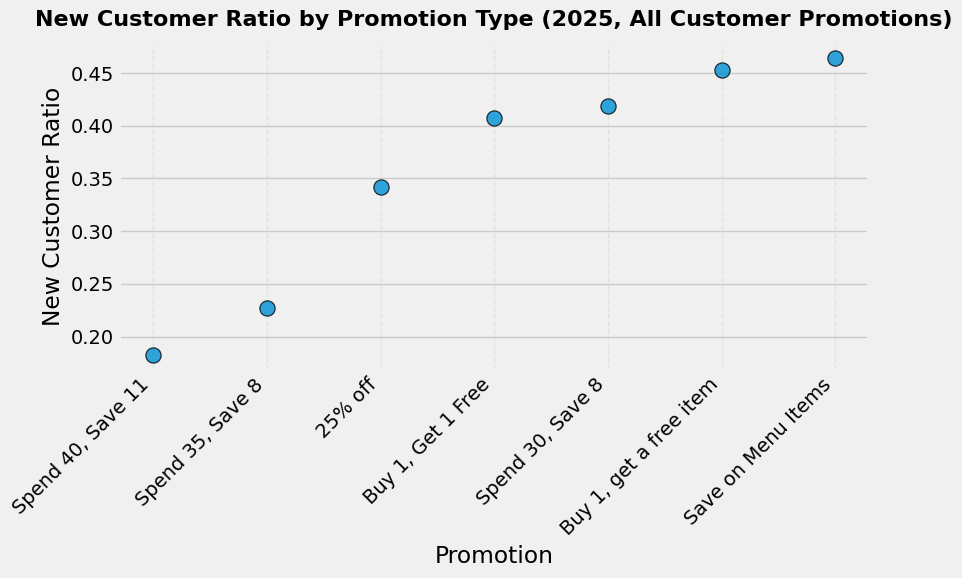

In [87]:
##2025
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=all_customers_table_2025,
    y="New_Customer_Ratio",
    x="Offer type",
    s=120,              
    alpha=0.8,       
    edgecolor="black"
)

plt.title(
    "New Customer Ratio by Promotion Type (2025, All Customer Promotions)",
    fontsize=16,
    weight="bold",
    pad=12
)

plt.xlabel("Promotion")
plt.ylabel("New Customer Ratio")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [88]:
##2024

#audience_filtered_table

all_customers_promos_2024 = promos2024[promos2024["Audience"] == "All customers"]

all_customers_table_2024 = (
    all_customers_promos_2024.groupby('Offer type')
    .agg(
        Total_Sales=('Sales (USD)', 'sum'),
        Total_New_Customers=('New customers', 'sum'),
        Total_Orders=('Orders', 'sum'),
        Total_Active_Days=('duration_days', 'sum')
    )
    .reset_index()
)

all_customers_table_2024["Total_Existing_Customers"] = all_customers_table_2024["Total_Orders"] - all_customers_table_2024["Total_New_Customers"]
all_customers_table_2024["New_Customer_Ratio"] = all_customers_table_2024["Total_New_Customers"] / all_customers_table_2024["Total_Orders"]
all_customers_table_2024["Existing_Customer_Ratio"] = all_customers_table_2024["Total_Existing_Customers"] / all_customers_table_2024["Total_Orders"]


all_customers_table_2024 = all_customers_table_2024.sort_values("New_Customer_Ratio", ascending=True).reset_index(drop=True)

all_customers_table_2024

,Offer type,Total_Sales,Total_New_Customers,Total_Orders,Total_Active_Days,Total_Existing_Customers,New_Customer_Ratio,Existing_Customer_Ratio
0,"25% off, up to $35",483495.0,3603,9289,550,5686,0.387878,0.612122
1,"Buy 1, Get 1 Free",497800.0,5690,12355,1329,6665,0.460542,0.539458
2,"30% off, up to $35",137881.0,1197,2562,348,1365,0.467213,0.532787


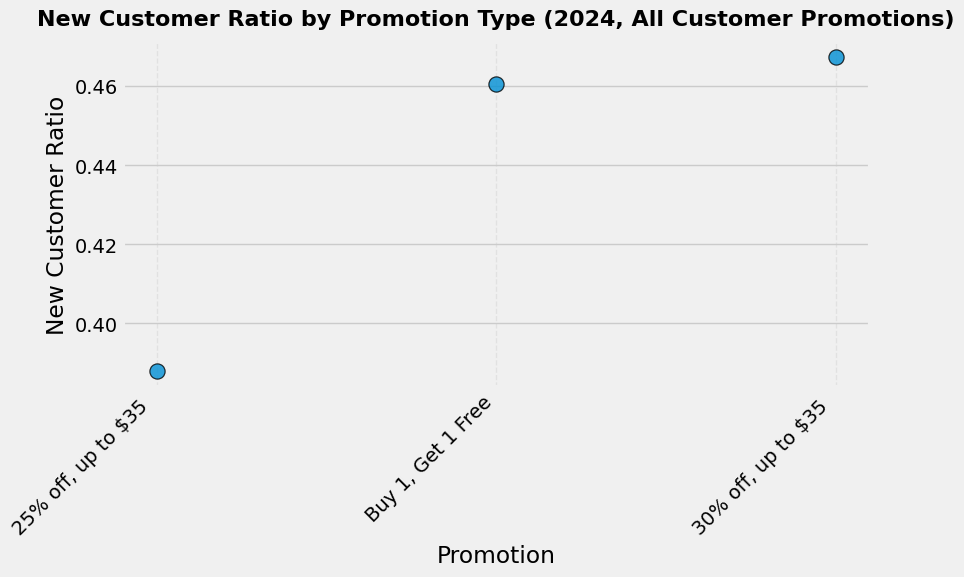

In [89]:
##2024
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=all_customers_table_2024,
    y="New_Customer_Ratio",
    x="Offer type",
    s=120,              
    alpha=0.8,       
    edgecolor="black"
)

plt.title(
    "New Customer Ratio by Promotion Type (2024, All Customer Promotions)",
    fontsize=16,
    weight="bold",
    pad=12
)

plt.xlabel("Promotion")
plt.ylabel("New Customer Ratio")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Section 3.2 Restrictive vs Non-Restrictive Analysis

In [90]:
##2025
#This uses only Promos offered to all customers
campaign_type_table_2025_2025 = all_customers_table.copy()

#I wanted to see if there was a noticeable difference between the restrictive and non_restrictive campaigns categories you have set up

restrictive_campaigns = [
    "Buy 1, Get 1 Free",
    "Buy 1, get a free item",
    "Save on Menu Items"
]

non_restrictive_campaigns = [
    "25% off",
    "25% off, up to $35 ",
    "30% off",
    "30% off, up to $35 ",
    "40% off, up to $30 ",
    "Spend 30, Save 12",
    "Spend 30, Save 8",
    "Spend 35, Save 7",
    "Spend 35, Save 10",
    "Spend 35, Save 8",
    "Spend 40, Save 10",
    "Spend 40, Save 11",
    "Spend 45, Save 12",
    "Spend 45, Save 15"
]
campaign_type_table_2025["Campaign_Group"] = "Other"
campaign_type_table_2025.loc[campaign_type_table_2025["Offer type"].isin(restrictive_campaigns), "Campaign_Group"] = "Restrictive"
campaign_type_table_2025.loc[campaign_type_table_2025["Offer type"].isin(non_restrictive_campaigns), "Campaign_Group"] = "Non-restrictive"

restrictive_vs_non_restrictive_2025 = (
    campaign_type_table_2025[campaign_type_table_2025["Campaign_Group"] != "Other"]
    .groupby("Campaign_Group", as_index=False)
    .agg(
        Total_New_Customers=("Total_New_Customers", "sum"),
        Total_Existing_Customers=("Total_Existing_Customers", "sum"),
        Total_Orders=("Total_Orders", "sum"),
    )
)

restrictive_vs_non_restrictive_2025 ["New_Customer_Ratio"] = (
    restrictive_vs_non_restrictive_2025 ["Total_New_Customers"] / restrictive_vs_non_restrictive_2025 ["Total_Orders"]
)

restrictive_vs_non_restrictive_2025 ["Existing_Customer_Ratio"] = (
    restrictive_vs_non_restrictive_2025 ["Total_Existing_Customers"] / restrictive_vs_non_restrictive_2025 ["Total_Orders"]
)


restrictive_vs_non_restrictive_2025 



NameError: name 'all_customers_table' is not defined

In [ ]:
##2024
#This uses only Promos offered to all customers
campaign_type_table_2024 = all_customers_table.copy()

#I wanted to see if there was a noticeable difference between the restrictive and non_restrictive campaigns categories you have set up

restrictive_campaigns = [
    "Buy 1, Get 1 Free",
    "Buy 1, get a free item",
    "Save on Menu Items"
]

non_restrictive_campaigns = [
    "25% off",
    "25% off, up to $35 ",
    "30% off",
    "30% off, up to $35 ",
    "40% off, up to $30 ",
    "Spend 30, Save 12",
    "Spend 30, Save 8",
    "Spend 35, Save 7",
    "Spend 35, Save 10",
    "Spend 35, Save 8",
    "Spend 40, Save 10",
    "Spend 40, Save 11",
    "Spend 45, Save 12",
    "Spend 45, Save 15"
]
campaign_type_table_2024["Campaign_Group"] = "Other"
campaign_type_table_2024.loc[campaign_type_table_2024["Offer type"].isin(restrictive_campaigns), "Campaign_Group"] = "Restrictive"
campaign_type_table_2024.loc[campaign_type_table_2024["Offer type"].isin(non_restrictive_campaigns), "Campaign_Group"] = "Non-restrictive"

restrictive_vs_non_restrictive_2024 = (
    campaign_type_table_2024[campaign_type_table_2024["Campaign_Group"] != "Other"]
    .groupby("Campaign_Group", as_index=False)
    .agg(
        Total_New_Customers=("Total_New_Customers", "sum"),
        Total_Existing_Customers=("Total_Existing_Customers", "sum"),
        Total_Orders=("Total_Orders", "sum"),
    )
)

restrictive_vs_non_restrictive_2024 ["New_Customer_Ratio"] = (
    restrictive_vs_non_restrictive_2024 ["Total_New_Customers"] / restrictive_vs_non_restrictive_2024 ["Total_Orders"]
)

restrictive_vs_non_restrictive_2024 ["Existing_Customer_Ratio"] = (
    restrictive_vs_non_restrictive_2024 ["Total_Existing_Customers"] / restrictive_vs_non_restrictive_2024 ["Total_Orders"]
)


restrictive_vs_non_restrictive_2024 


NameError: name 'all_customers_table' is not defined

### Section 3.3: Monthly Analysis

In [ ]:
##2025
promo_months_2025 = promos2025.copy()

# Ensure dates are datetime
promo_months_2025["Start date"] = pd.to_datetime(promo_months_2025["Start date"])
promo_months_2025["End date"] = pd.to_datetime(promo_months_2025["End date"])

# Function to get months active
def get_active_months(row):
    months = pd.period_range(start=row["Start date"], end=row["End date"], freq="M")
    return [m.strftime("%Y-%m") for m in months]

promo_months_2025["months_active"] = promo_months_2025.apply(get_active_months, axis=1)

# Keep only single-month campaigns
promo_months_single_month_2025 = promo_months_2025[promo_months_2025["months_active"].str.len() == 1].copy()

# Convert months_active list to string (or datetime)
promo_months_single_month_2025["months_active"] = promo_months_single_month_2025["months_active"].str[0]

# Compute new customer ratios per promo type per month
promo_months_ratios_2025 = (
    promo_months_single_month_2025
    .groupby(["Offer type", "months_active"])
    .agg(
        total_new_customers=("New customers", "sum"),
        total_orders=("Orders", "sum")
    )
    .reset_index()
)

promo_months_ratios_2025["new_customer_ratio"] = (
    promo_months_ratios_2025["total_new_customers"] / promo_months_ratios_2025["total_orders"]
)

# Sort by month
promo_months_ratios_2025["months_active"] = pd.to_datetime(promo_months_ratios_2025["months_active"])
promo_months_ratios_2025 = promo_months_ratios_2025.sort_values("months_active").reset_index(drop=True)

promo_months_ratios_2025

,Offer type,months_active,total_new_customers,total_orders,new_customer_ratio
0,"Buy 1, Get 1 Free",2025-04-01,1337,2916,0.458505
1,"Spend 30, Save 8",2025-04-01,1777,1779,0.998876
2,"Spend 35, Save 8",2025-04-01,346,1844,0.187636
3,"40% off, up to $30",2025-05-01,67,167,0.401198
4,"Buy 1, Get 1 Free",2025-05-01,2536,5294,0.479033
5,Save on Menu Items,2025-05-01,837,1724,0.485499
6,"Spend 30, Save 12",2025-05-01,543,1339,0.405527
7,"Buy 1, Get 1 Free",2025-06-01,748,1804,0.414634
8,"Spend 40, Save 11",2025-10-01,199,1092,0.182234
9,"Buy 1, Get 1 Free",2025-11-01,5366,14328,0.374511


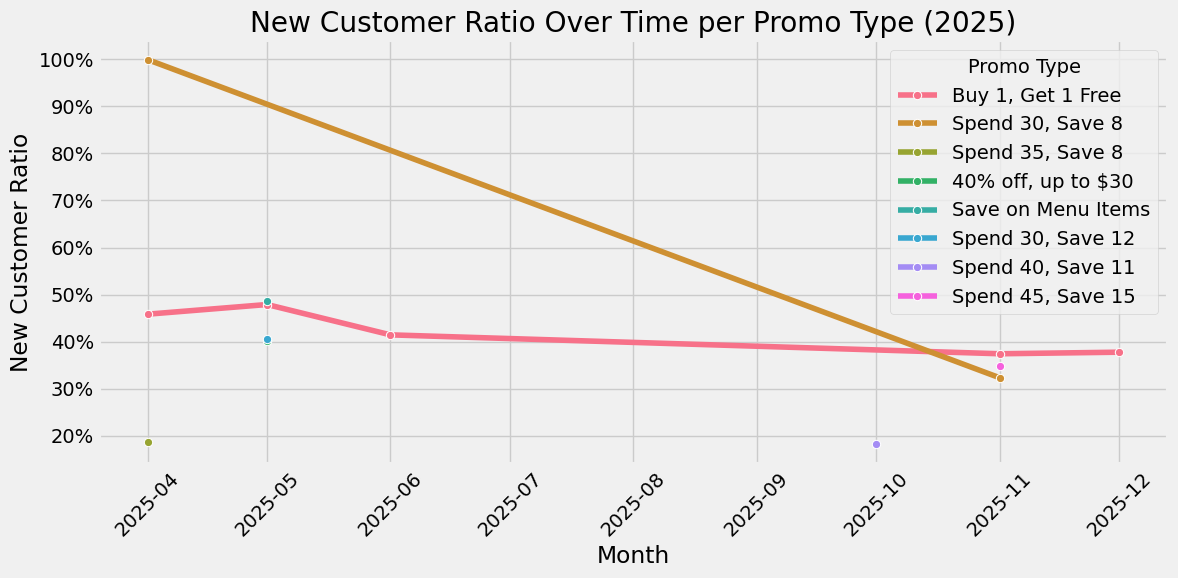

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=promo_months_ratios_2025,
    x="months_active",
    y="new_customer_ratio",
    hue="Offer type",
    marker="o"
)

plt.title("New Customer Ratio Over Time per Promo Type (2025)")
plt.xlabel("Month")
plt.ylabel("New Customer Ratio")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: "{:.0%}".format(y)))
plt.legend(title="Promo Type")
plt.tight_layout()
plt.show()

In [ ]:
##2024
promo_months_2024 = promos2024.copy()

# Ensure dates are datetime
promo_months_2024["Start date"] = pd.to_datetime(promo_months_2024["Start date"])
promo_months_2024["End date"] = pd.to_datetime(promo_months_2024["End date"])

# Function to get months active
def get_active_months(row):
    months = pd.period_range(start=row["Start date"], end=row["End date"], freq="M")
    return [m.strftime("%Y-%m") for m in months]

promo_months_2024["months_active"] = promo_months_2024.apply(get_active_months, axis=1)

# Keep only single-month campaigns
promo_months_single_month_2024 = promo_months_2024[promo_months_2024["months_active"].str.len() == 1].copy()

# Convert months_active list to string (or datetime)
promo_months_single_month_2024["months_active"] = promo_months_single_month_2024["months_active"].str[0]

# Compute new customer ratios per promo type per month
promo_months_ratios_2024 = (
    promo_months_single_month_2024
    .groupby(["Offer type", "months_active"])
    .agg(
        total_new_customers=("New customers", "sum"),
        total_orders=("Orders", "sum")
    )
    .reset_index()
)

promo_months_ratios_2024["new_customer_ratio"] = (
    promo_months_ratios_2024["total_new_customers"] / promo_months_ratios_2024["total_orders"]
)

# Sort by month
promo_months_ratios_2024["months_active"] = pd.to_datetime(promo_months_ratios_2024["months_active"])
promo_months_ratios_2024 = promo_months_ratios_2024.sort_values("months_active").reset_index(drop=True)

promo_months_ratios_2024

,Offer type,months_active,total_new_customers,total_orders,new_customer_ratio
0,"Buy 1, Get 1 Free",2024-02-01,1697,2083,0.814690
1,"Buy 1, Get 1 Free",2024-03-01,2353,4894,0.480793
2,"Buy 1, Get 1 Free",2024-06-01,406,637,0.637363
3,"Spend 40, Save 10",2024-06-01,70,70,1.000000
4,"Spend 45, Save 12",2024-06-01,123,123,1.000000
5,"Buy 1, Get 1 Free",2024-08-01,2402,5853,0.410388
6,"Buy 1, Get 1 Free",2024-12-01,101,158,0.639241


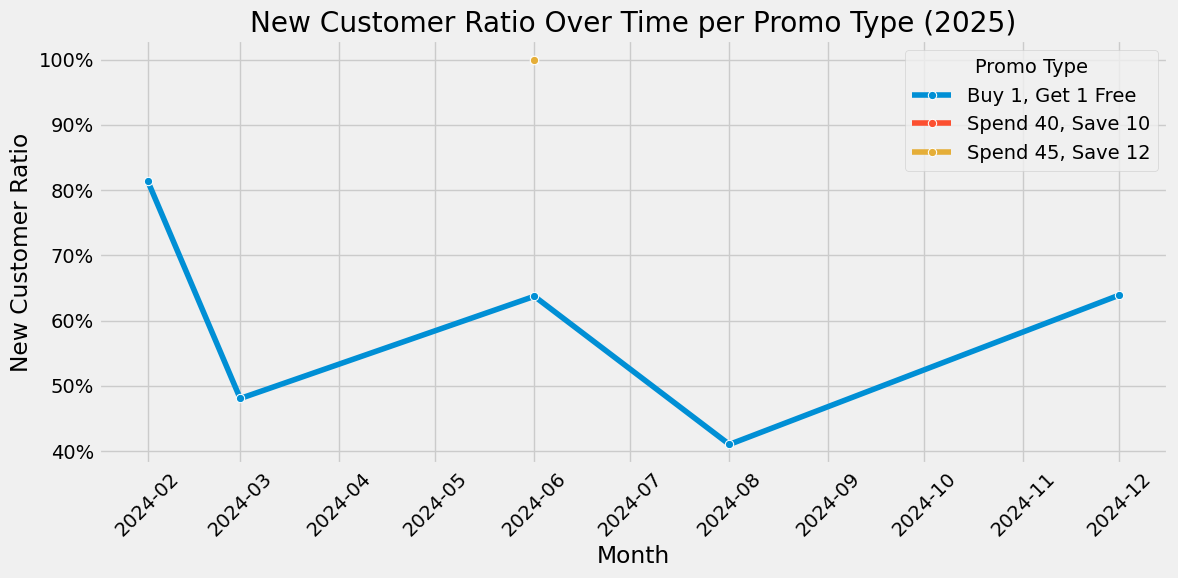

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=promo_months_ratios_2024,
    x="months_active",
    y="new_customer_ratio",
    hue="Offer type",
    marker="o"
)

plt.title("New Customer Ratio Over Time per Promo Type (2025)")
plt.xlabel("Month")
plt.ylabel("New Customer Ratio")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: "{:.0%}".format(y)))
plt.legend(title="Promo Type")
plt.tight_layout()
plt.show()

## Section 4: AOV (WIP)

In [ ]:
aov_data = sales_data.copy()
aov_data = aov_data[['Store Name', 'Dining Mode', 'Order Channel', 'Order Status',
       'Order Date', 'Order Day', 'Customer Uber-Membership Status',
       'Sales (excl. tax)', 'Promo', 'No Promo', 'Buy 1, Get 1 Free', 'Spend 30, Save 8',
       'Spend 45, Save 15', 'Spend 40, Save 11', 'Save on Menu Items',
       '25% off', '30% off', 'Spend 35, Save 8', 'Spend 30, Save 12',
       'Spend 35, Save 7', 'Buy 1, get a free item', 'Spend 35, Save 10',
       '40% off, up to $30 ', '30% off, up to $35 ', '25% off, up to $35 ',
       'Spend 40, Save 10', 'Spend 45, Save 12', 'Restrictive',
       'Non-Restrictive', 'Both', 'Campaign Type']]
aov_data_clean = aov_data.copy()



aov_data_clean["Order Date"] = pd.to_datetime(aov_data_clean["Order Date"])
aov_data_clean["Year"] = aov_data_clean["Order Date"].dt.year
aov_data_clean["DayOfWeek"] = aov_data_clean["Order Date"].dt.day_name()
aov_data_clean["Month"] = aov_data_clean["Order Date"].dt.month_name()

aov_filtered = aov_data_clean.loc[
    aov_data_clean["Year"].isin([2024, 2025])
].copy()


## Section 4.1: AOV by Day, Weekday, Month

In [ ]:

aov_filtered = aov_data_clean[aov_data_clean["Year"].isin([2024, 2025])]

aov_by_day = (
    aov_filtered
    .groupby(["Year", "DayOfWeek"])["Sales (excl. tax)"]
    .mean()
    .reset_index(name="AOV")
)

aov_pivot = aov_by_day.pivot(
    index="DayOfWeek",
    columns="Year",
    values="AOV"
)

# Order weekdays
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
aov_pivot = aov_pivot.reindex(day_order)
aov_pivot

Year,2024,2025
DayOfWeek,,
Monday,32.401943,34.778643
Tuesday,33.566649,35.866376
Wednesday,33.604471,35.015406
Thursday,33.736555,35.395561
Friday,35.287255,37.647640
Saturday,35.800173,37.912968
Sunday,35.069840,37.292283


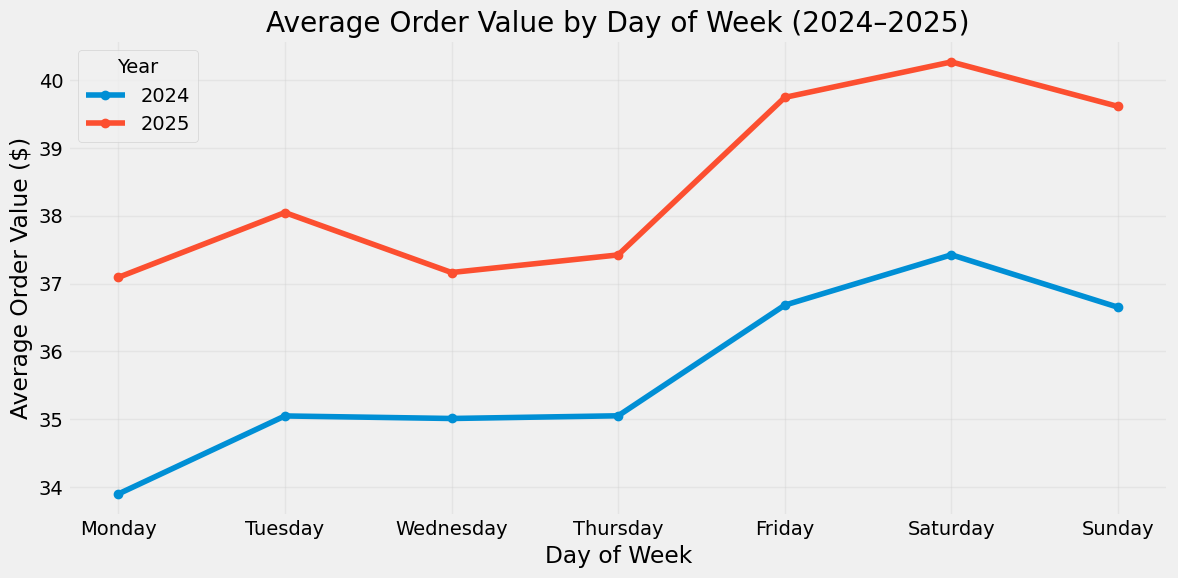

In [ ]:
#Weekly Plot
plt.figure(figsize=(12, 6))
for year in aov_weekday_pivot.columns:
    plt.plot(
        aov_weekday_pivot.index,
        aov_weekday_pivot[year],
        marker='o',
        label=str(year)
    )

plt.title("Average Order Value by Day of Week (2024–2025)")
plt.xlabel("Day of Week")
plt.ylabel("Average Order Value ($)")
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
aov_filtered = aov_data_clean[aov_data_clean["Year"].isin([2024, 2025])]


month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

aov_by_month = (
    aov_filtered
    .groupby(["Year", "Month"])["Sales (excl. tax)"]
    .mean()
    .reset_index(name="AOV")
)

aov_by_month["Month"] = pd.Categorical(
    aov_by_month["Month"],
    categories=month_order,
    ordered=True
)

aov_by_month = aov_by_month.sort_values(["Year", "Month"])

aov_month_pivot = aov_by_month.pivot(
    index="Month",
    columns="Year",
    values="AOV"
)

aov_month_pivot

Year,2024,2025
Month,,
January,32.892154,35.029712
February,33.856681,36.111016
March,34.466544,34.521029
April,33.537309,35.760403
May,34.719760,37.202873
June,34.643053,37.324166
July,33.530870,36.101785
August,34.766162,37.491926
September,34.109006,35.703603


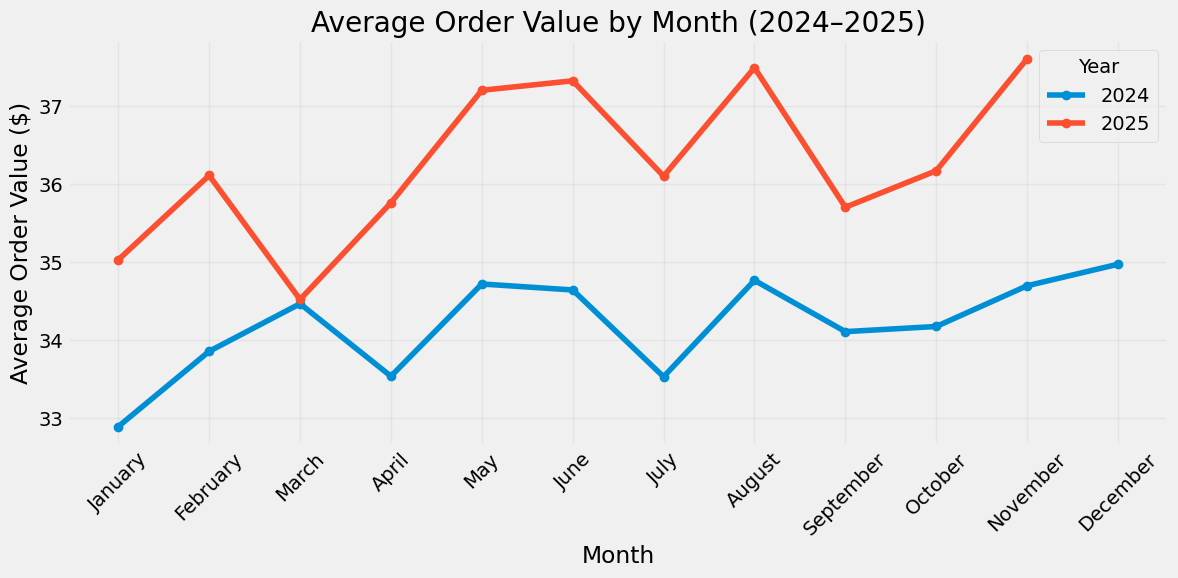

In [ ]:
# Monthly Plot
aov_month_pivot = aov_month_pivot.reindex(month_order)
plt.figure(figsize=(12, 6))
for year in aov_month_pivot.columns:
    plt.plot(aov_month_pivot.index, aov_month_pivot[year], marker='o', label=str(year))

plt.title("Average Order Value by Month (2024–2025)")
plt.xlabel("Month")
plt.ylabel("Average Order Value ($)")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#Daily
#Remove refunds
aov_data_clean = aov_data[aov_data["Sales (excl. tax)"] > 0].copy()

aov_data_clean["Order Date"] = pd.to_datetime(aov_data_clean["Order Date"])

#Get time cols
aov_data_clean["Year"] = aov_data_clean["Order Date"].dt.year
aov_data_clean["Month"] = aov_data_clean["Order Date"].dt.month_name()

aov_filtered["MonthNum"] = aov_filtered["Order Date"].dt.month
aov_filtered["Day"] = aov_filtered["Order Date"].dt.day

aov_filtered["MonthDay"] = aov_filtered["Order Date"].dt.strftime("%b-%d")

aov_by_day_of_year = (
    aov_filtered
    .groupby(["Year", "MonthNum", "Day", "MonthDay"])["Sales (excl. tax)"]
    .mean()
    .reset_index(name="AOV")
)

aov_by_day_of_year = aov_by_day_of_year.sort_values(
    ["Year", "MonthNum", "Day"]
)

aov_dayofyear_pivot = aov_by_day_of_year.pivot(
    index="MonthDay",
    columns="Year",
    values="AOV"
)


calendar_order = (
    aov_by_day_of_year
    .drop_duplicates("MonthDay")
    .sort_values(["MonthNum", "Day"])["MonthDay"]
)

aov_dayofyear_pivot = aov_dayofyear_pivot.reindex(calendar_order)

aov_dayofyear_pivot

Year,2024,2025
MonthDay,,
Jan-01,35.952481,34.018591
Jan-02,30.375771,30.313190
Jan-03,29.816233,36.926833
Jan-04,33.508825,34.999814
Jan-05,33.539636,34.963495
...,...,...
Dec-27,40.150116,NaN
Dec-28,35.613634,NaN
Dec-29,36.140960,NaN


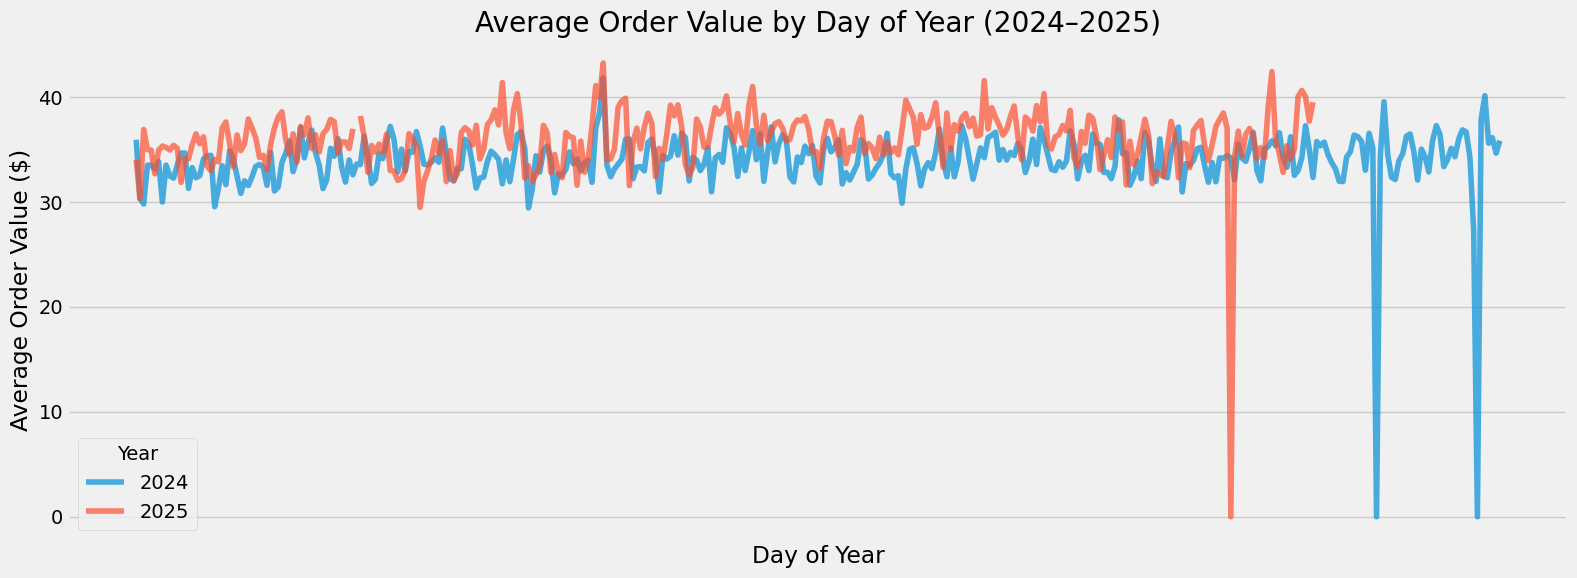

In [ ]:
plt.figure(figsize=(16, 6))

for year in aov_dayofyear_pivot.columns:
    plt.plot(
        aov_dayofyear_pivot.index,
        aov_dayofyear_pivot[year],
        label=str(year),
        alpha=0.7
    )

plt.title("Average Order Value by Day of Year (2024–2025)")
plt.xlabel("Day of Year")
plt.ylabel("Average Order Value ($)")
plt.legend(title="Year")
plt.xticks([])

plt.tight_layout()
plt.show()

### Section 4.2: AOV by Promo/Non-Promo

In [ ]:
aov_promo_year = (
    aov_filtered
    .groupby(["Year", "Promo"])["Sales (excl. tax)"]
    .mean()
    .reset_index(name="AOV")
)

aov_promo_year["Promo"] = aov_promo_year["Promo"].map(
    {1: "Promo", 0: "No Promo"}
)

aov_promo_year

,Year,Promo,AOV
0,2024,No Promo,32.450991
1,2024,Promo,46.401896
2,2025,No Promo,29.632037
3,2025,Promo,45.782320


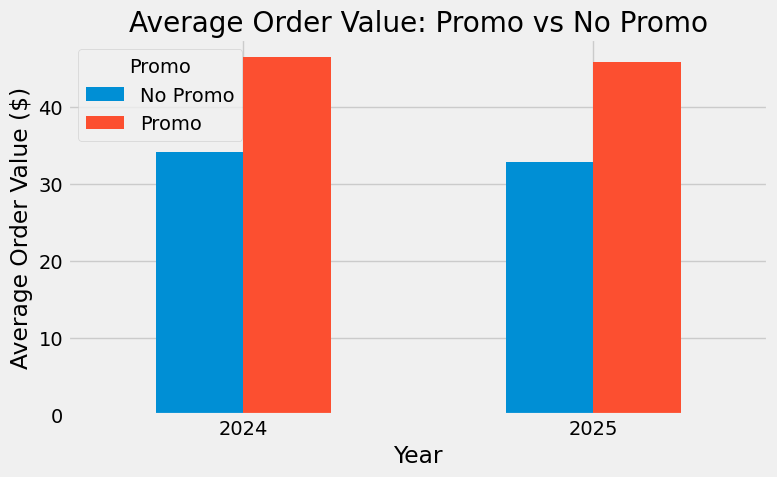

In [ ]:
aov_promo_year_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Order Value: Promo vs No Promo")
plt.ylabel("Average Order Value ($)")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print(aov_filtered["Promo"].head())

167    0
168    0
169    0
170    0
171    0
Name: Promo, dtype: int64


In [ ]:
# Ensure datetime
aov_data_clean["Order Date"] = pd.to_datetime(aov_data_clean["Order Date"])

aov_data_clean["Year"] = aov_data_clean["Order Date"].dt.year
aov_data_clean["DayOfWeek"] = aov_data_clean["Order Date"].dt.day_name()

# Keep only real years
aov_filtered = aov_data_clean[aov_data_clean["Year"].isin([2024, 2025])]

aov_filtered["PromoStatus"] = aov_filtered["Promo"].map({1: "Promo", 0: "No Promo"})


aov_by_weekday_promo = (
    aov_filtered
    .groupby(["Year", "DayOfWeek", "PromoStatus"])["Sales (excl. tax)"]
    .mean()
    .reset_index(name="AOV")
)


aov_weekday_promo_pivot = aov_by_weekday_promo.pivot(
    index="DayOfWeek",
    columns=["Year", "PromoStatus"],
    values="AOV"
)


weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

aov_weekday_promo_pivot = aov_weekday_promo_pivot.reindex(weekday_order)

aov_weekday_promo_pivot

C:\Users\willi\AppData\Local\Temp\ipykernel_21788\2598989786.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aov_filtered["PromoStatus"] = aov_filtered["Promo"].map({1: "Promo", 0: "No Promo"})


Year              2024                  2025           
PromoStatus   No Promo      Promo   No Promo      Promo
DayOfWeek                                              
Monday       32.371332  44.924857  31.379543  44.714136
Tuesday      33.508563  46.446300  32.443827  46.219790
Wednesday    33.477462  45.175351  32.393539  45.054515
Thursday     33.366674  46.026594  32.037265  45.295213
Friday       34.945321  46.693770  33.943876  46.580788
Saturday     35.597734  47.875058  34.347807  46.514536
Sunday       35.066124  47.300845  33.448965  45.669163

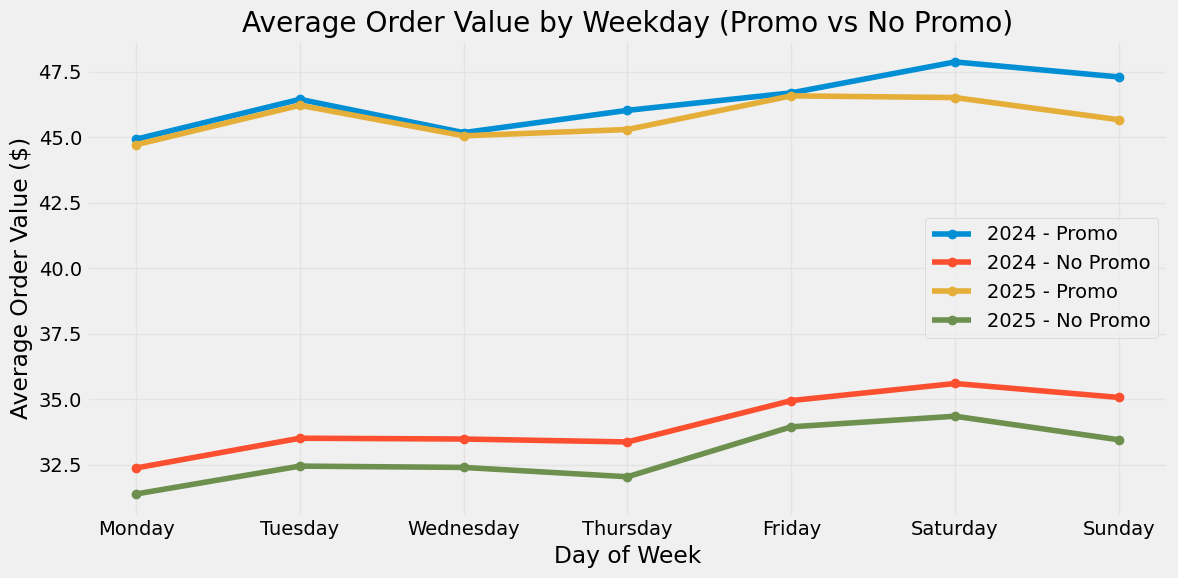

In [ ]:
plt.figure(figsize=(12, 6))

for year in [2024, 2025]:
    for promo_status in ["Promo", "No Promo"]:
        plt.plot(
            aov_weekday_promo_pivot.index,
            aov_weekday_promo_pivot[(year, promo_status)],
            marker='o',
            label=f"{year} - {promo_status}"
        )

plt.title("Average Order Value by Weekday (Promo vs No Promo)")
plt.xlabel("Day of Week")
plt.ylabel("Average Order Value ($)")
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
aov_promo_month["Month"] = pd.Categorical(
    aov_promo_month["Month"],
    categories=month_order,
    ordered=True
)

aov_promo_month = aov_promo_month.sort_values(["Year", "Month"])

aov_promo_month_pivot = aov_promo_month.pivot(
    index="Month",
    columns=["Year", "Promo"],
    values="AOV"
)

aov_promo_month_pivot

Year            2024                  2025           
Promo       No Promo      Promo   No Promo      Promo
Month                                                
January    34.195749        NaN  36.654802        NaN
February   33.935287  41.528164  36.688413        NaN
March      33.865083  40.808061  35.460383  44.614014
April      34.826166        NaN  30.498426  45.854188
May        35.937963        NaN  30.009133  47.086188
June       35.450945  45.772096  24.240815  44.358481
July       34.748364        NaN  28.994276  44.001118
August     34.110658  39.749078  32.760695  47.564065
September  35.394418        NaN  33.863029  46.788622
October    35.441220        NaN  32.751339  47.279523
November   30.816086  52.436788  30.233854  45.467455
December   24.423556  52.799228        NaN        NaN

<Figure size 1200x600 with 0 Axes>

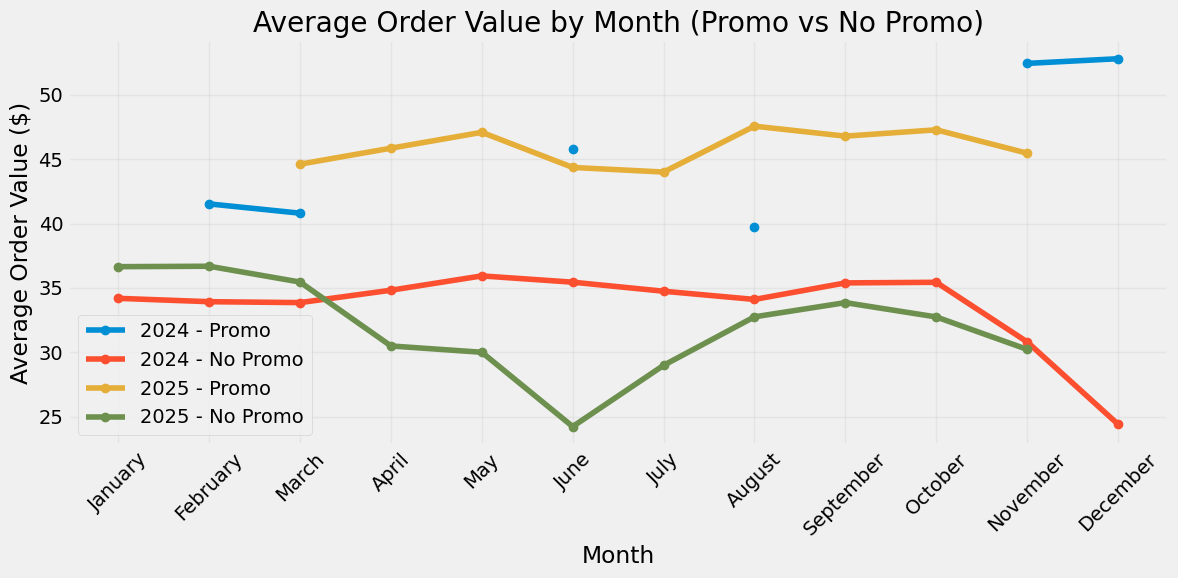

In [ ]:
plt.figure(figsize=(12, 6))

plt.figure(figsize=(12, 6))

for year in [2024, 2025]:
    for status in ["Promo", "No Promo"]:
        plt.plot(
            aov_promo_month_pivot.index,
            aov_promo_month_pivot[(year, status)],
            marker='o',
            label=f"{year} - {status}"
        )

plt.title("Average Order Value by Month (Promo vs No Promo)")
plt.xlabel("Month")
plt.ylabel("Average Order Value ($)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
aov_data_clean["Order Date"] = pd.to_datetime(aov_data_clean["Order Date"])

aov_data_clean["Year"] = aov_data_clean["Order Date"].dt.year
aov_data_clean["DayOfWeek"] = aov_data_clean["Order Date"].dt.day_name()

# Keep only real years
aov_filtered = aov_data_clean[aov_data_clean["Year"].isin([2024, 2025])]


aov_filtered["PromoStatus"] = aov_filtered["Promo"].map({1: "Promo", 0: "No Promo"})
aov_filtered["MonthDay"] = aov_filtered["Order Date"].dt.strftime("%b-%d")
aov_filtered["MonthNum"] = aov_filtered["Order Date"].dt.month
aov_filtered["DayNum"] = aov_filtered["Order Date"].dt.day

aov_by_day = (
    aov_filtered
    .groupby(["Year", "MonthNum", "DayNum", "MonthDay", "PromoStatus"])["Sales (excl. tax)"]
    .mean()
    .reset_index(name="AOV")
)

aov_day_pivot = aov_by_day.pivot(
    index="MonthDay",
    columns=["Year", "PromoStatus"],
    values="AOV"
)

# Sort by calendar order
calendar_order = (
    aov_by_day
    .drop_duplicates("MonthDay")
    .sort_values(["MonthNum", "DayNum"])["MonthDay"]
)

aov_day_pivot = aov_day_pivot.reindex(calendar_order)
aov_day_pivot

C:\Users\willi\AppData\Local\Temp\ipykernel_21788\633373972.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aov_filtered["PromoStatus"] = aov_filtered["Promo"].map({1: "Promo", 0: "No Promo"})
C:\Users\willi\AppData\Local\Temp\ipykernel_21788\633373972.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aov_filtered["MonthDay"] = aov_filtered["Order Date"].dt.strftime("%b-%d")
C:\Users\willi\AppData\Local\Temp\ipykernel_21788\633373972.py:12: SettingWithCopyWarning: 
A value is trying to be set on a c

Year              2024                  2025      
PromoStatus   No Promo      Promo   No Promo Promo
MonthDay                                          
Jan-01       36.995590        NaN  37.977651   NaN
Jan-02       31.641429        NaN  34.577431   NaN
Jan-03       31.472690        NaN  38.785295   NaN
Jan-04       35.145302        NaN  36.796870   NaN
Jan-05       34.806541        NaN  36.824080   NaN
...                ...        ...        ...   ...
Dec-27       24.137448  55.639471        NaN   NaN
Dec-28       27.079029  52.545742        NaN   NaN
Dec-29       24.854109  52.751030        NaN   NaN
Dec-30       24.469954  51.815000        NaN   NaN
Dec-31       24.568770  54.396965        NaN   NaN

[364 rows x 4 columns]

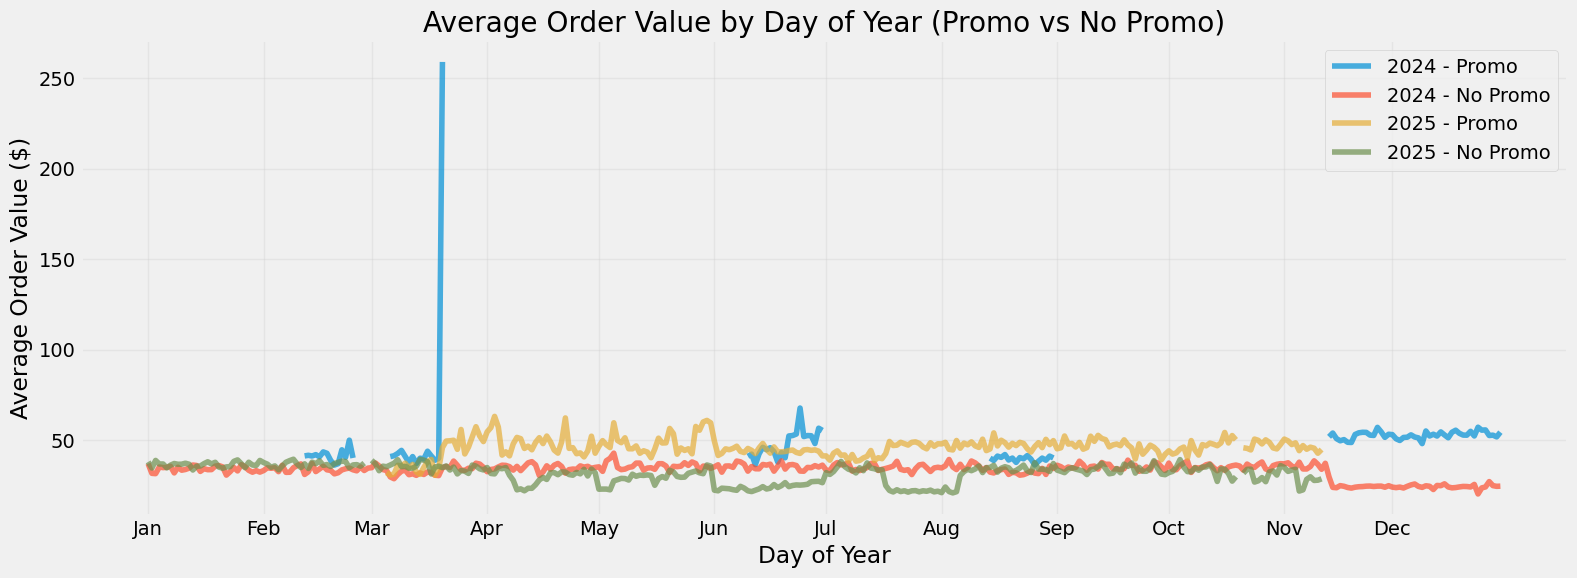

In [ ]:
plt.figure(figsize=(16, 6))

for year in [2024, 2025]:
    for status in ["Promo", "No Promo"]:
        plt.plot(
            aov_day_pivot.index,
            aov_day_pivot[(year, status)],
            label=f"{year} - {status}",
            alpha=0.7
        )

plt.title("Average Order Value by Day of Year (Promo vs No Promo)")
plt.xlabel("Day of Year")
plt.ylabel("Average Order Value ($)")

# Show only months on x-axis for readability
month_positions = [i for i, label in enumerate(aov_day_pivot.index) if label.endswith("-01")]
month_labels = [label.split("-")[0] for label in aov_day_pivot.index[month_positions]]
plt.xticks(ticks=month_positions, labels=month_labels)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Section 4.3 AOV Restrictive/Non_restrictive

In [ ]:

       
aov_data_clean["Order Date"] = pd.to_datetime(aov_data["Order Date"])

aov_data_clean["Year"] = aov_data_clean["Order Date"].dt.year
aov_data_clean["DayOfWeek"] = aov_data_clean["Order Date"].dt.day_name()


aov_filtered = aov_data_clean[aov_data_clean["Year"].isin([2024, 2025])]


# Example: assuming your DataFrame is called aov_filtered
# Make sure flags are integers (0/1)
aov_filtered["Restrictive"] = aov_filtered["Restrictive"].astype(int)
aov_filtered["Non-Restrictive"] = aov_filtered["Non-Restrictive"].astype(int)
aov_filtered["Both"] = aov_filtered["Both"].astype(int)

# Define function to categorize each row
def promo_category(row):
    if row["Both"] == 1:
        return "Both"
    elif row["Restrictive"] == 1:
        return "Restrictive only"
    elif row["Non-Restrictive"] == 1:
        return "Non-Restrictive only"
    else:
        return "No Promo"

# Apply the function
aov_filtered["PromoCategory"] = aov_filtered.apply(promo_category, axis=1)

summary = (
    aov_filtered.groupby(["DayOfWeek", "PromoCategory"])
                .size()
                .groupby(level=0)
                .apply(lambda x: 100 * x / x.sum())
                .unstack(fill_value=0)
                .round(2)
)

summary.index = summary.index.get_level_values(0)
summary.index.name = None
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

summary = summary.reindex(weekday_order)

summary

C:\Users\willi\AppData\Local\Temp\ipykernel_21788\1166979766.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aov_filtered["Restrictive"] = aov_filtered["Restrictive"].astype(int)
C:\Users\willi\AppData\Local\Temp\ipykernel_21788\1166979766.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aov_filtered["Non-Restrictive"] = aov_filtered["Non-Restrictive"].astype(int)
C:\Users\willi\AppData\Local\Temp\ipykernel_21788\1166979766.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

PromoCategory,Both,No Promo,Non-Restrictive only,Restrictive only
Monday,41.86,39.76,7.45,10.94
Tuesday,41.89,36.39,6.68,15.05
Wednesday,42.63,39.50,5.41,12.47
Thursday,43.33,39.09,5.13,12.45
Friday,42.91,38.58,6.22,12.29
Saturday,43.44,38.00,6.74,11.81
Sunday,42.71,37.29,8.17,11.83


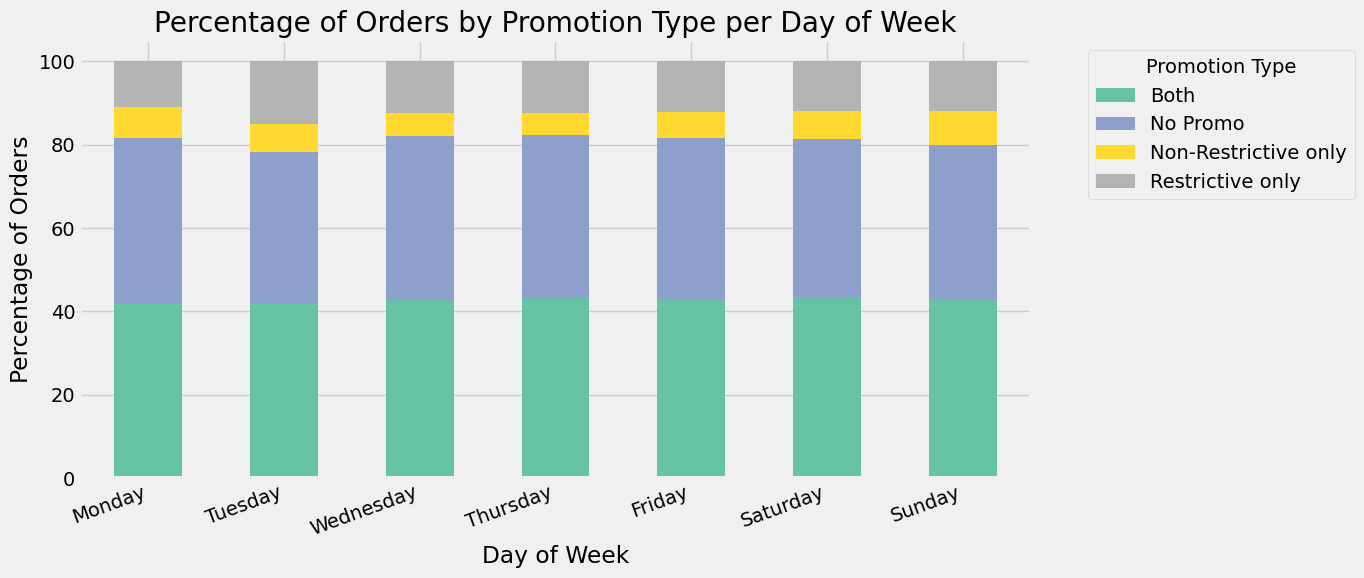

In [ ]:
ax = summary.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    colormap="Set2"
)

ax.set_title("Percentage of Orders by Promotion Type per Day of Week")
ax.set_ylabel("Percentage of Orders")
ax.set_xlabel("Day of Week")

ax.set_xticklabels(summary.index, rotation=20, ha="right")

ax.legend(
    title="Promotion Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Section 5 Cannibalization (WIP)

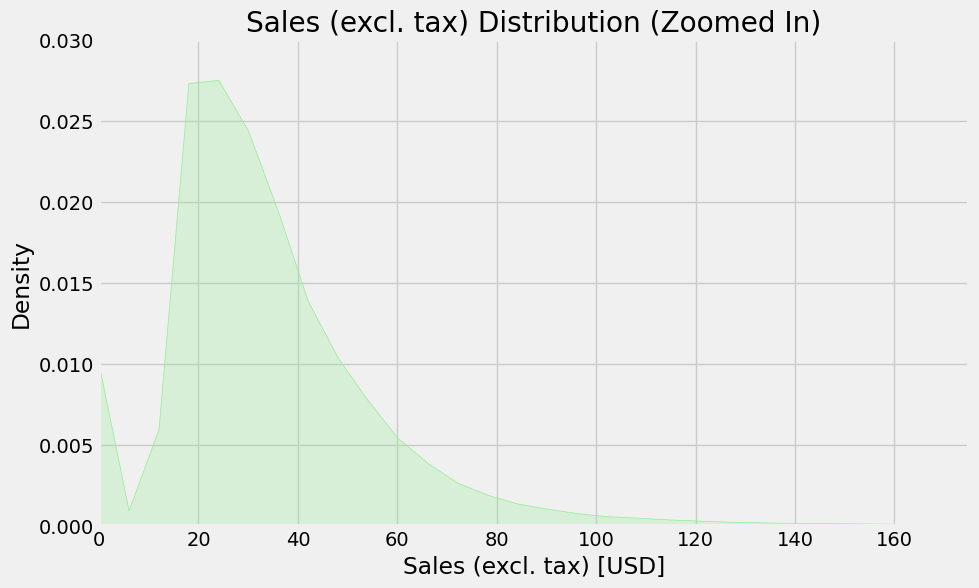

In [ ]:
## Total sales
plt.figure(figsize=(10,6))
sns.kdeplot(sales_data['Sales (excl. tax)'], fill=True, color='lightgreen', bw_adjust=1)
plt.title('Sales (excl. tax) Distribution (Zoomed In)')
plt.xlabel('Sales (excl. tax) [USD]')
plt.ylabel('Density')

plt.xlim(0, 175)
plt.ylim(0, 0.03)

plt.show()

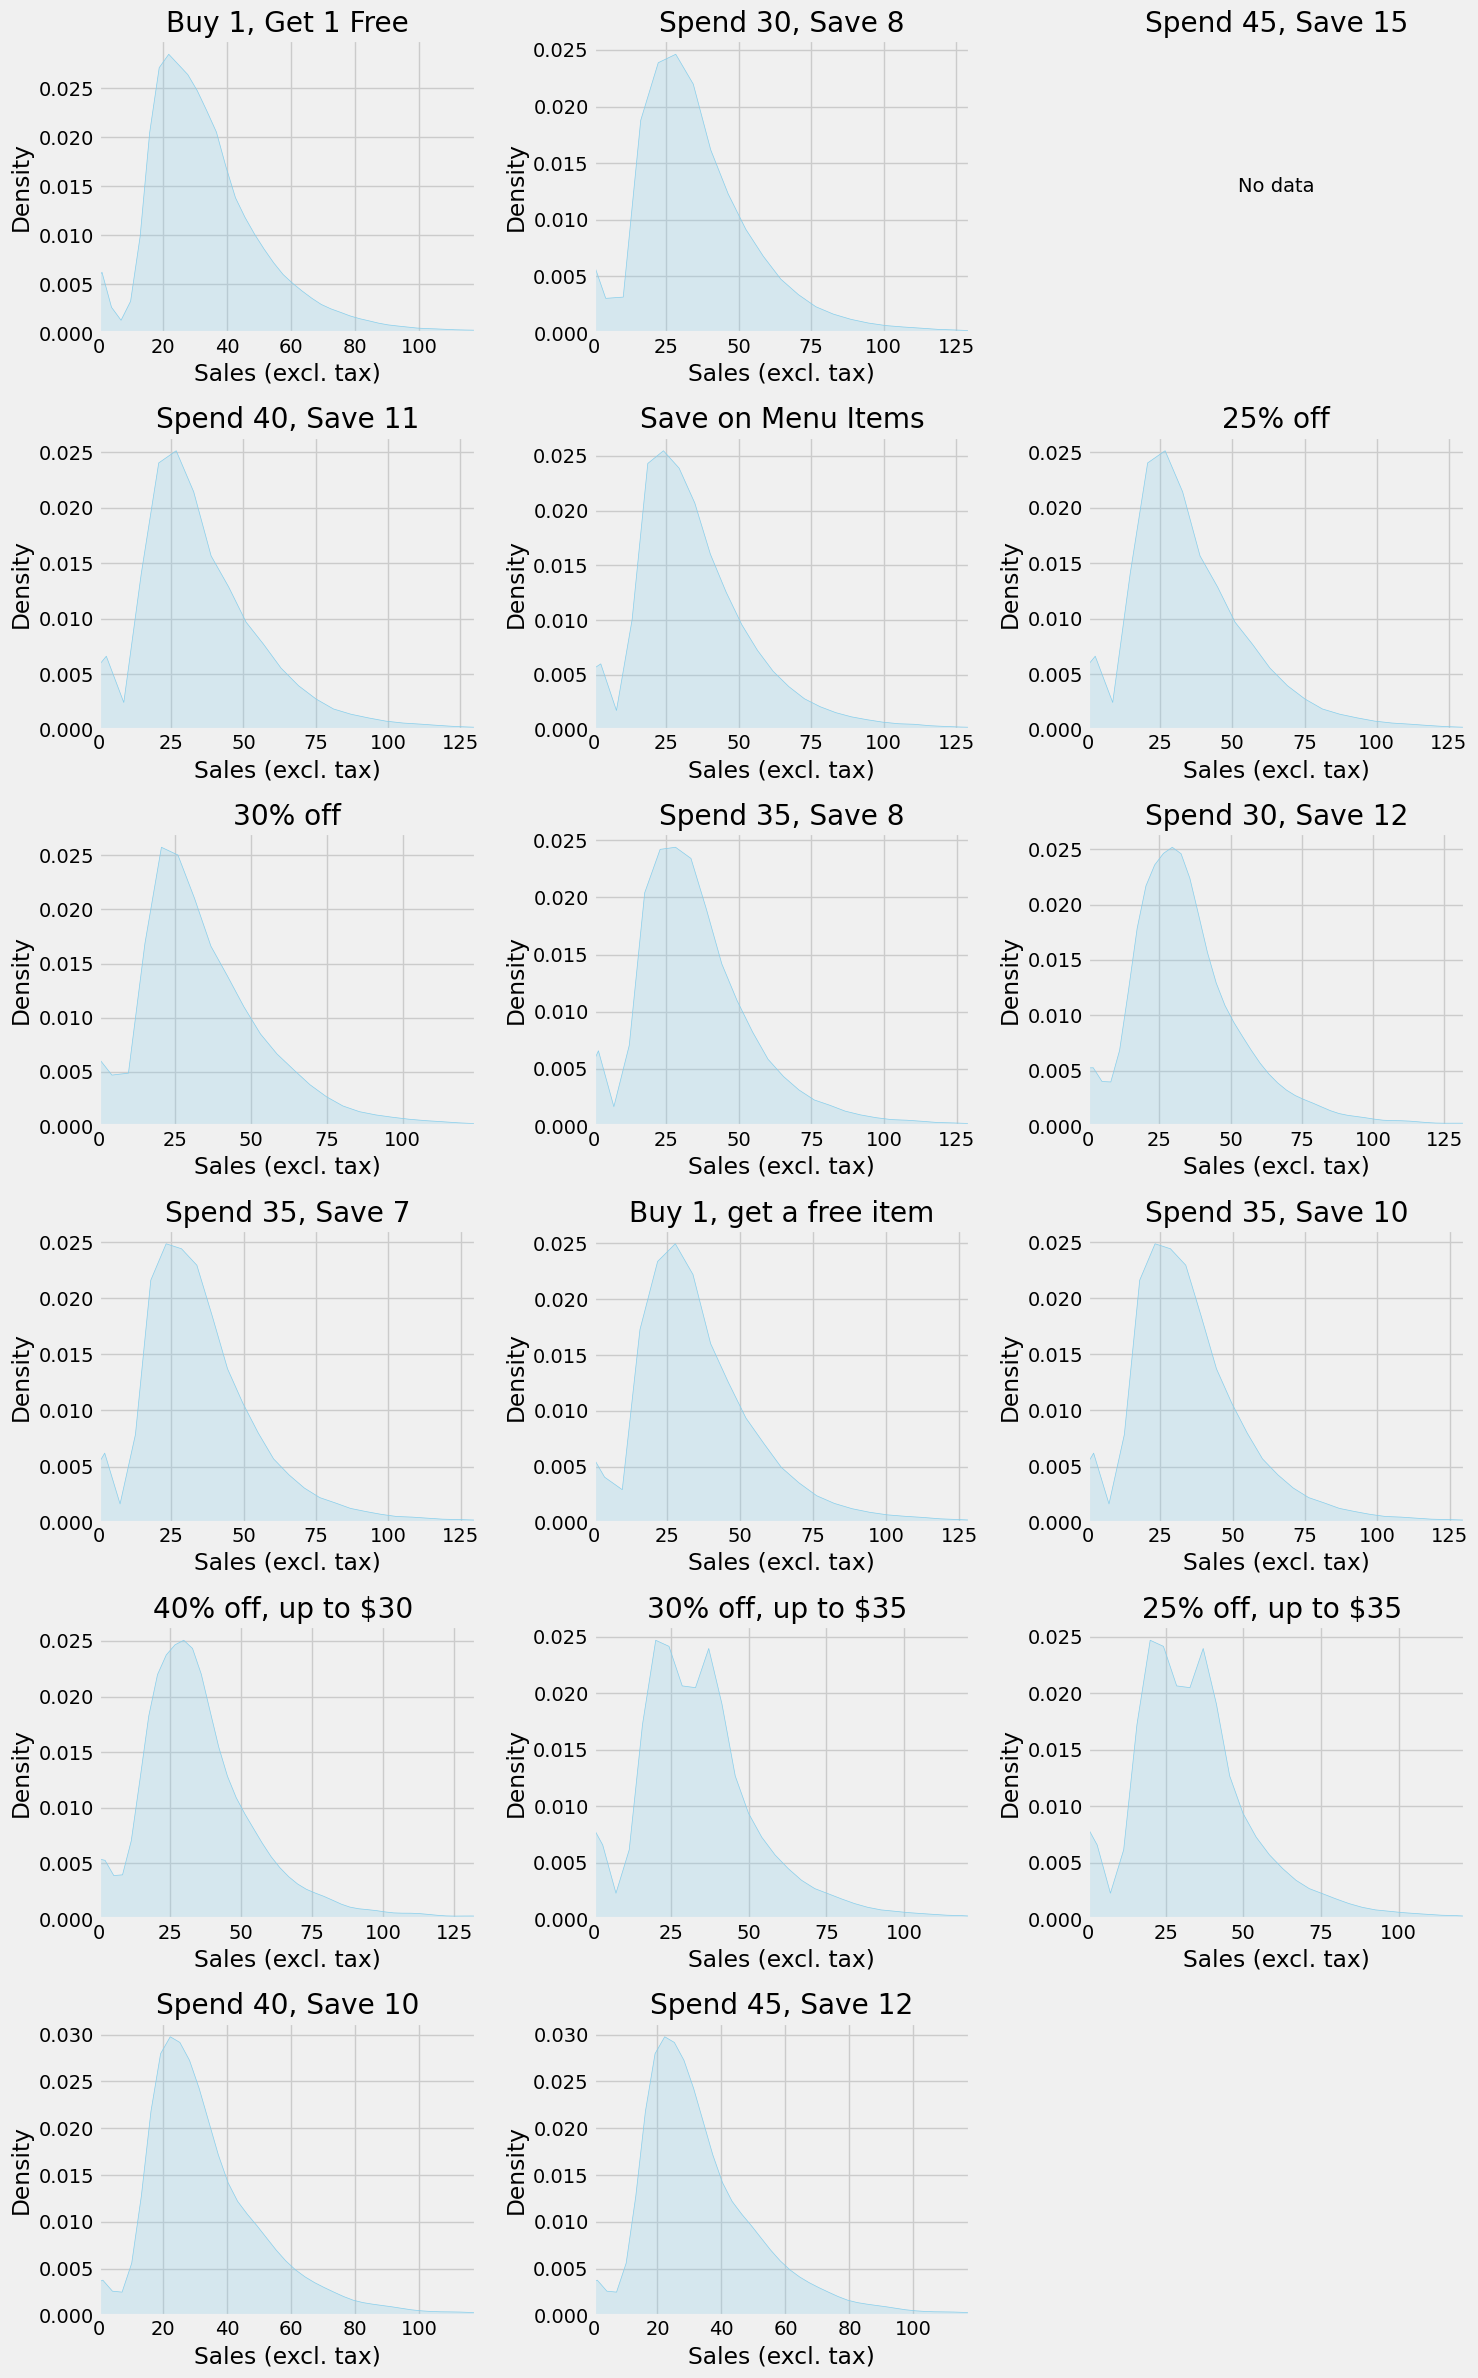

In [ ]:
promo_cols = [
    'Buy 1, Get 1 Free', 'Spend 30, Save 8', 'Spend 45, Save 15',
    'Spend 40, Save 11', 'Save on Menu Items', '25% off', '30% off',
    'Spend 35, Save 8', 'Spend 30, Save 12', 'Spend 35, Save 7',
    'Buy 1, get a free item', 'Spend 35, Save 10', '40% off, up to $30 ',
    '30% off, up to $35 ', '25% off, up to $35 ', 'Spend 40, Save 10',
    'Spend 45, Save 12'
]

# Determine rows and columns for subplots
n = len(promo_cols)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(cols*5, rows*4))

for i, promo in enumerate(promo_cols):
    plt.subplot(rows, cols, i+1)
    
    # Filter sales for this promo
    promo_sales = df.loc[df[promo] == 1, 'Sales (excl. tax)']
    
    if len(promo_sales) > 0:
        sns.kdeplot(promo_sales, fill=True, color='skyblue', bw_adjust=1)
        plt.title(promo)
        plt.xlabel('Sales (excl. tax)')
        plt.ylabel('Density')
        plt.xlim(0, promo_sales.quantile(0.99)) 
    else:
        plt.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center')
        plt.title(promo)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
cannibalization = sales_data.copy()
cannibalization = cannibalization[["Store Name", "Sales (excl. tax)", "Promo Net", "Promo %", "Promo", "No Promo",
       'Spend 30, Save 8',
       'Spend 45, Save 15', 'Spend 40, Save 11',
       'Spend 35, Save 8', 'Spend 30, Save 12',
       'Spend 35, Save 7', 'Spend 35, Save 10',
       'Spend 40, Save 10', 'Spend 45, Save 12']]


promos = {
    'Spend 30, Save 8': {'threshold': 30, 'savings': 8},
    'Spend 45, Save 15': {'threshold': 45, 'savings': 15},
    'Spend 40, Save 11': {'threshold': 40, 'savings': 11},
    'Spend 35, Save 8': {'threshold': 35, 'savings': 8},
    'Spend 30, Save 12': {'threshold': 30, 'savings': 12},
    'Spend 35, Save 7': {'threshold': 35, 'savings': 7},
    'Spend 35, Save 10': {'threshold': 35, 'savings': 10},
    'Spend 40, Save 10': {'threshold': 40, 'savings': 10},
    'Spend 45, Save 12': {'threshold': 45, 'savings': 12},
}

def normal_sales_in_range(df, threshold, savings):
    # Only non-promo sales
    non_promo_sales = df[df['No Promo'] == 1]['Sales (excl. tax)']
    
    # Count how many are in the [threshold, threshold + savings] range
    count_in_range = ((non_promo_sales >= threshold) & 
                      (non_promo_sales <= threshold + savings)).sum()
    
    total_non_promo = len(non_promo_sales)
    
    return count_in_range, total_non_promo

def lost_sales_in_range(df, promo, threshold, savings):
    # Filter promo sales
    promo_sales = df[df[promo] == 1]['Sales (excl. tax)']
    
    # Calculate lost amount
    lost = threshold - (promo_sales - savings)
    lost = lost.apply(lambda x: min(x, savings)).clip(lower=0)
    
    # Sales that incur loss
    lost_sales = promo_sales[(lost > 0) & (promo_sales > 0)]
    
    # Count how many are in [threshold, threshold+savings] range
    count_in_range = ((lost_sales >= threshold) & (lost_sales <= threshold + savings)).sum()
    
    total_lost_sales = len(lost_sales)
    
    return count_in_range, total_lost_sales

In [ ]:
results = []

results = []

for promo, vals in promos.items():
    threshold = vals['threshold']
    savings = vals['savings']
    
    # --- Non-promo baseline (exclude refunds) ---
    non_promo_sales = df[(df['No Promo'] == 1) & (df['Sales (excl. tax)'] > 0)]['Sales (excl. tax)']
    normal_count = ((non_promo_sales >= threshold) & (non_promo_sales <= threshold + savings)).sum()
    normal_total = len(non_promo_sales)
    normal_pct = normal_count / normal_total * 100 if normal_total > 0 else 0
    
    # --- Promo sales (exclude refunds) ---
    promo_sales = df[(df[promo] == 1) & (df['Sales (excl. tax)'] > 0)]['Sales (excl. tax)']
    promo_total = len(promo_sales)
    
    # Calculate lost amount per row
    lost = threshold - (promo_sales - savings)
    lost = lost.apply(lambda x: min(x, savings)).clip(lower=0)
    
    # --- Promo loss Count in Range ---
    mask_in_range = (lost > 0) & (promo_sales >= threshold) & (promo_sales <= threshold + savings)
    lost_sales_in_range = promo_sales[mask_in_range]
    lost_count_in_range = len(lost_sales_in_range)
    
    # --- Lost Total (all promo orders incurring any loss) ---
    lost_total = (lost > 0).sum()
    
    # --- Promo % in Range ---
    lost_pct_in_range = lost_count_in_range / promo_total * 100 if promo_total > 0 else 0
    
    # --- Promo Amount in Range ---
    lost_amount_in_range = lost[mask_in_range].sum()
    
    # --- Impact calculation ---
    if normal_pct > 0:
        impact = ((lost_pct_in_range / normal_pct) - 1) * lost_amount_in_range
    else:
        impact = 0
    
    # --- Lost Total * Savings ---
    potential_lost_revenue = ((lost_total-lost_count_in_range) * savings) + impact
    
    # Store results
    results.append({
        'Promo': promo,
        'Threshold': threshold,
        'Savings': savings,
        'Normal Count in Range': normal_count,
        'Normal Total': normal_total,
        'Normal % in Range': normal_pct,
        'Promo loss Count in Range': lost_count_in_range,
        'Lost Total': lost_total,
        'Promo % in Range': lost_pct_in_range,
        'Promo Amount in Range': lost_amount_in_range,
        'Impact': impact,
        'Lost Total * Savings': potential_lost_revenue
    })

# Convert to DataFrame
cannibalization_summary = pd.DataFrame(results)
cannibalization_summary = cannibalization_summary.sort_values('Impact', ascending=False)

# Total Impact across all promos
total_impact = cannibalization_summary['Impact'].sum()
total_potential_lost = cannibalization_summary['Lost Total * Savings'].sum()

cannibalization_summary




,Promo,Threshold,Savings,Normal Count in Range,Normal Total,Normal % in Range,Promo loss Count in Range,Lost Total,Promo % in Range,Promo Amount in Range,Impact,Lost Total * Savings
6,"Spend 35, Save 10",35,10,36296,288894,12.563778,15275,60020,18.751995,82715.86,40741.225849,488191.225849
0,"Spend 30, Save 8",30,8,45956,288894,15.907565,29052,91572,19.507151,120359.99,27235.229194,527395.229194
2,"Spend 40, Save 11",40,11,29920,288894,10.356740,9754,51220,15.023951,58234.86,26243.240509,482369.240509
3,"Spend 35, Save 8",35,8,30470,288894,10.547121,11167,49333,15.875069,47768.83,24130.741491,329458.741491
5,"Spend 35, Save 7",35,7,27340,288894,9.463679,11467,56212,14.077193,42868.23,20898.131031,334113.131031
4,"Spend 30, Save 12",30,12,59871,288894,20.724210,2153,5211,28.953739,14510.75,5762.179901,42458.179901
8,"Spend 45, Save 12",45,12,25418,288894,8.798383,1345,10890,10.884519,8624.26,2044.850801,116584.850801
7,"Spend 40, Save 10",40,10,27672,288894,9.578600,1416,10202,11.459092,7109.05,1395.664685,89255.664685
1,"Spend 45, Save 15",45,15,29531,288894,10.222088,0,0,0.000000,0.00,-0.000000,0.000000


In [ ]:
print(f"\nTotal estimated impact across all promos: {total_impact}")
print(f"Total Lost Total * Savings across all promos: {total_potential_lost}")


Total estimated impact across all promos: 148451.2634618212
Total Lost Total * Savings across all promos: 2409826.2634618212


In [ ]:
2979576

In [ ]:
#Analysis
#I would say this is a fairly conservative estimate, but we can highly confident that cannibalization is at least this much.
# The theoretical max if everyone promo sale cannibalized would be Total Lost Total * Savings, but this is highly unlikley

#Promo is Promo
#Threshold is the threshold needed to use the promo
#Savings is saving from Promo
#Normal Count in Range is the amount of non-promo orders that fall in the range threshold to (threshold + savings), for example the range for Spend 35, Save 10 is 35-45.
#Normal Total is amount of no promo order
#Normal % in Range = Normal Count/Normal Total
#Promo Lost Count in Range is amount of sales using the promo in threshold
#Lost total is the amount of sales using the promo in threshold or below it. If its below its due to stacking coupons. Some of these people are probably cannibalzing but since they don't naturally fall into the range we want we can include them when we use the distributions to predict intent.
#Promo Amount in Range is Total lost dollars from promo orders in range
#Impact is the amount we think is cannibalized intentional by people moving up slighty in to the range



In [91]:
sales_data.columns

Index(['Store Name', 'Dining Mode', 'Order Channel', 'Order Status',
       'Order Date', 'Order Day', 'Customer Uber-Membership Status',
       'Sales (excl. tax)', 'Offers on items (incl. tax)',
       'Offer Redemption Fee', 'Marketing Adjustment',
       'Total Sales after Adjustments (incl tax)', 'Marketplace Fee',
       'Marketplace fee %', 'Delivery Fee', 'Tips', 'Total payout ',
       'Markup Amount', 'OrderID', 'Rating', 'Rating Comment', 'Promo Net',
       'Promo %', 'Is Promo', 'is 30%', 'Hour', 'Day Part', 'Fiscal Week',
       'Fee', 'Promo', 'No Promo', 'Buy 1, Get 1 Free', 'Spend 30, Save 8',
       'Spend 45, Save 15', 'Spend 40, Save 11', 'Save on Menu Items',
       '25% off', '30% off', 'Spend 35, Save 8', 'Spend 30, Save 12',
       'Spend 35, Save 7', 'Buy 1, get a free item', 'Spend 35, Save 10',
       '40% off, up to $30 ', '30% off, up to $35 ', '25% off, up to $35 ',
       'Spend 40, Save 10', 'Spend 45, Save 12', 'Restrictive',
       'Non-Restrictive', '

In [ ]:
promo_count = cannibalization['Spend 30, Save 8'].sum()
print(f"Number of orders using 'Spend 30, Save 8': {promo_count}")

# Or using filtering
promo_count2 = len(cannibalization[cannibalization['Spend 30, Save 8'] == 1])
print(f"Number of orders using 'Spend 30, Save 8' (alternative method): {promo_count2}")

Number of orders using 'Spend 30, Save 8': 159431
Number of orders using 'Spend 30, Save 8' (alternative method): 159431
